# 2026 January 19 CMEs: Analysis of Geoeffectiveness

In [1]:
# Conda dependencies are listed under dro_spec.txt
import os
import sys
import copy
from datetime import datetime, timedelta
import getpass
import logging
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pdb
import pickle
import requests
import scipy.io
from scipy import stats
import scipy
import warnings
import pandas as pd
import matplotlib.dates as mdates
import astropy.units as u
from scipy.optimize import curve_fit, least_squares, minimize
import time
from sunpy.coordinates import HeliographicStonyhurst, HeliocentricEarthEcliptic
import urllib
#import multiprocess as mp

import seaborn as sns

from functions import data
from functions import predict

from functions import data_frame_transforms as dft
from functions import position_frame_transforms as pft
from functions import functions_insitu_analysis as fia

#import spacepy

#from predstorm.config.conscnts import AU, dist_to_L1
#from predstorm.predict import dst_loss_function

#warnings.filterwarnings('ignore') # some numpy mean-of-empty-slice runtime warnings

sns.set_style('whitegrid', {'xtick.bottom': True, 'grid.color': 'gainsboro'})
sns.set_context('paper')

data_path='cmerun_v1/dro/'

c0 = "xkcd:black"
c1 = "xkcd:magenta"
c2 = "xkcd:orange"
c3 = "xkcd:azure"
c4 = "xkcd:green"
#data_path = '/data/aswo/data/insitu_python/'

Kernels path loaded: /Volumes/External/data/kernels/
Kernels path loaded: /Volumes/External/data/kernels/
Kernels path loaded: /Volumes/External/data/kernels/


## Load processed data

In [4]:
syn_dro0  = pd.read_csv(data_path+'synthetic_dro_000_0_74au_20260118_v1.txt', sep='\t', comment='#')
syn_dro0 = syn_dro0.dropna(axis=1, how='all') #df.columns = ["col1", "col2", ...]
syn_dro0.columns = ['time', 'bt', 'bx', 'by', 'bz', 'vt', 'vx', 'vy', 'vz', 'np', 'tp', 'beta']
syn_dro0.time = pd.to_datetime(syn_dro0.time)
print(syn_dro0.bt)
#, columns=['time', 'bt', 'bx', 'by', 'bz', 'vt', 'vx', 'vy', 'vz', 'np', 'tp', 'beta']
#Btot [nT]	Br [nT]		Bt [nT]		Bn [nT]		Vtot [km/s]	Vr [km/s]	Vt [km/s]	Vn [km/s]	Np [cm-3]	Tp [K]		beta

0      9.5358
1      9.4723
2      9.4179
3      9.3580
4      9.3019
        ...  
211    5.8531
212    5.8235
213    5.7967
214    5.7699
215    5.7430
Name: bt, Length: 216, dtype: float64


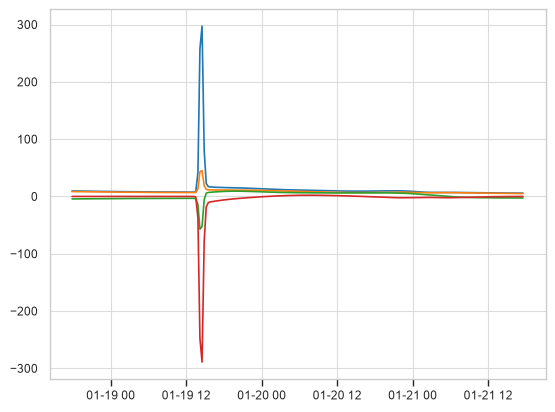

In [5]:
plt.plot(syn_dro0.time, syn_dro0.bt)
plt.plot(syn_dro0.time, syn_dro0.bx)
plt.plot(syn_dro0.time, syn_dro0.by)
plt.plot(syn_dro0.time, syn_dro0.bz)

In [20]:
#Plotly imports
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio
from plotly.offline import iplot, init_notebook_mode
import plotly.express as px

nrows=2

fig = make_subplots(rows=nrows, cols=1, shared_xaxes=True)
sc = copy.deepcopy(syn_dro0)

#for column, color in zip(['b_x', 'b_y', 'b_z', 'b_tot'], ['red', 'green', 'blue', 'black']):
fig.add_trace(go.Scatter(x=sc.time, y=sc.bx, name='Bx',line_color='red'), row=1, col=1)
fig.add_trace(go.Scatter(x=sc.time, y=sc.by, name='By',line_color='green'), row=1, col=1)
fig.add_trace(go.Scatter(x=sc.time, y=sc.bz, name='Bz',line_color='blue'), row=1, col=1)
fig.add_trace(go.Scatter(x=sc.time, y=sc.bt, name='Bt',line_color='black'), row=1, col=1)

fig.add_trace(go.Scatter(x=sc.time, y=sc.vt, name='vt',line_color='red'), row=2, col=1)

## Calculate Dst & SYM-H

In [6]:
n_ens = 10000
#nt = len(sc_0_hour.time)

# -----------------------------
# Randomized solar wind inputs
# -----------------------------

def calc_pennati(sc_in, n_ens,sc_name): 

    nt = len(sc_in.time)
    
    const0 = 0.375602483749
    const1 = -0.447044461966

    a1 = 0.707106769085
    a2 = 0.318309873343
    a3 = 0.197246953845
    a4 = 4.448832511902
    a5 = 0.090346775949
    
    if sc_name == 'Wind':

        np_rand = sc_in.np

        vt_rand = sc_in.vt

        bz_rand = sc_in.bz

        Dst = -1.0 * np.ones(nt)

        Pdyn = 1.6726e-6 * np_rand * vt_rand**2
        Ey   = -vt_rand * bz_rand * 1e-3

        for i in range(nt - 1):
    
            p_dyn = Pdyn[i]
            e_y = Ey[i]
            dst = Dst[i]
    
            term1 = np.sqrt(np.sqrt(a1 * p_dyn))
    
            term2 = np.maximum(a3 * dst + a4 * e_y, a5 * dst)
    
            Dst[i + 1] = (dst + const0 + const1 * term1 * (a2 * p_dyn + term2))

    

    if sc_name == 'SolO':
        
        np_rand = np.abs(np.random.normal(loc=sc_in.np, scale=sc_in.np_err, size=(n_ens, nt)))
    
        vt_rand = np.abs(np.random.normal(loc=sc_in.vt, scale=sc_in.vt_err, size=(n_ens, nt)))
    
        bz_rand = np.random.normal(loc=sc_in.bz, scale=sc_in.bz_err, size=(n_ens, nt))
    
        Dst = -1.0 * np.ones((n_ens, nt))

        Pdyn = 1.6726e-6 * np_rand * vt_rand**2
        Ey   = -vt_rand * bz_rand * 1e-3
        
        for i in range(nt - 1):
    
            p_dyn = Pdyn[:, i]
            e_y = Ey[:, i]
            dst = Dst[:, i]
    
            term1 = np.sqrt(np.sqrt(a1 * p_dyn))
    
            term2 = np.maximum(a3 * dst + a4 * e_y, a5 * dst)
    
            Dst[:, i + 1] = (dst + const0 + const1 * term1 * (a2 * p_dyn + term2))
            
        
    return Pdyn, Ey, Dst, [np_rand, vt_rand, bz_rand]


In [7]:
def calc_pennati_min(sc_in, n_ens, sc_name): 
    
    nt = len(sc_in.time)
    
    const0 = 0.375602483749
    const1 = -0.447044461966

    a1 = 0.707106769085
    a2 = 0.318309873343
    a3 = 0.197246953845
    a4 = 4.448832511902
    a5 = 0.090346775949
    
    if sc_name == 'Wind':

        np_rand = sc_in.np

        vt_rand = sc_in.vt

        bz_rand = sc_in.bz

        Dst = -1.0 * np.ones(nt)

        Pdyn = 1.6726e-6 * np_rand * vt_rand**2
        Ey   = -vt_rand * bz_rand * 1e-3

    

    if sc_name == 'SolO':
        
        np_rand = np.abs(np.random.normal(loc=sc_in.np, scale=sc_in.np_err, size=(n_ens, nt)))
    
        vt_rand = np.abs(np.random.normal(loc=sc_in.vt, scale=sc_in.vt_err, size=(n_ens, nt)))
    
        bz_rand = np.random.normal(loc=sc_in.bz, scale=sc_in.bz_err, size=(n_ens, nt))
    
        Dst = -1.0 * np.ones((n_ens, nt))

        Pdyn = 1.6726e-6 * np_rand * vt_rand**2
        Ey   = -vt_rand * bz_rand * 1e-3
        
        
    return Pdyn, Ey, [np_rand, vt_rand, bz_rand]

## Far upstream processing (ELEvo + scaling and expanding)

In [57]:
donki_dict = {"time21_5": ['2026-01-18T19:51Z'], "longitude": [-4.7], "latitude": [-10.7], "halfAngle": [32.2], "speed": [1420.4], "associatedCMEID": ['SYNTHETIC_CME_20260118T1951Z']}
data_donki = pd.DataFrame(donki_dict)
data_donki.time21_5 = pd.to_datetime(data_donki.time21_5)
data_donki = data_donki.iloc[0]
#data_donki.colums = ['time21_5,', 'longitude', 'latitude', 'halfAngle', 'speed']
print(data_donki)

time21_5              2026-01-18 19:51:00+00:00
longitude                                  -4.7
latitude                                  -10.7
halfAngle                                  32.2
speed                                    1420.4
associatedCMEID    SYNTHETIC_CME_20260118T1951Z
Name: 0, dtype: object


In [46]:
# Load s/c positions:
load_pos = False

if load_pos:
    positions_path = "../"

    pos = pickle.load(open('../positions_from_2010_to_2030_HEEQ_10min_rad_ed.p', 'rb'))
    psp = pos['psp']
    solo = pos['solo']
    bepi = pos['bepi']
    sta = pos['sta']
    l1 = pos['l1']
    earth = pos['earth']
    
    pickle.dump([earth, l1, solo], open('../pos_earth_l1_solo_heq_10min_rad.p', 'wb'))

In [ ]:
syn_pos = pd.read_csv(data_path+"coords_dro_000__0_74au.txt", sep='\t', comment='#') #Seq	Time			R [Rs]		heeLat [°]	heeLon [°]
syn_pos = syn_pos.dropna(axis=1, how='all')
syn_pos.columns = ['seq', 'time', 'r', 'lat', 'lon']
syn_pos.time = pd.to_datetime(syn_pos.time)
syn_pos.r = syn_pos.r*u.Rsun.to(u.au)
print(syn_pos.r)
print(syn_pos)



0      0.740000
1      0.740000
2      0.740000
3      0.740000
4      0.740000
         ...   
211    0.740608
212    0.740615
213    0.740621
214    0.740627
215    0.740632
Name: r, Length: 216, dtype: float64
     seq                time         r  lat      lon
0      2 2026-01-18 17:50:30  0.740000  0.0  0.01071
1      3 2026-01-18 18:11:48  0.740000  0.0  0.02183
2      4 2026-01-18 18:30:13  0.740000  0.0  0.03145
3      5 2026-01-18 18:50:47  0.740000  0.0  0.04220
4      6 2026-01-18 19:10:17  0.740000  0.0  0.05238
..   ...                 ...       ...  ...      ...
211  213 2026-01-21 16:10:13  0.740608  0.0  2.21261
212  214 2026-01-21 16:32:10  0.740615  0.0  2.22403
213  215 2026-01-21 16:51:57  0.740621  0.0  2.23433
214  216 2026-01-21 17:11:45  0.740627  0.0  2.24463
215  217 2026-01-21 17:31:34  0.740632  0.0  2.25495

[216 rows x 5 columns]


In [47]:
# Load positions of Earth, L1 and Solar Orbiter

earth, l1, solo = pickle.load(open('../pos_earth_l1_solo_heq_10min_rad.p', 'rb'))

In [49]:
solo_start = pd.to_datetime(datetime(2026,1,19,13,30,8)).tz_localize('UTC')
print(solo_start)
print(solo_start.tzinfo)
print(data_donki.time21_5.tzinfo)


#solo_start = datetime(2025,11,11,15,45)

2026-01-19 13:30:08+00:00
UTC
UTC


In [51]:
#set initial parameters

sc_measure_name = 'SolarOrbiter'

print('Sub-L1 monitor s/c: ', sc_measure_name)

distance0 = 21.5*u.solRad.to(u.km)

t0 = data_donki.time21_5
print(t0)
t0_num = mdates.date2num(t0)


print('Launch time (21.5 R_Sun): ', t0)
print('Start ICME @ SolO: ', solo_start)

gamma_init = 0.1                  
ambient_wind_init = 400.
speed_init = data_donki.speed
x0 = [speed_init, ambient_wind_init, gamma_init]
print('Initial Parameters (DONKI): ', gamma_init, ambient_wind_init, speed_init)

kindays = 10
n_ensemble = 50000
halfwidth = np.deg2rad(35.)
#halfwidth = np.deg2rad(data_donki.halfAngle[index])
res_in_min = 10
f = 0.7

Sub-L1 monitor s/c:  SolarOrbiter
2026-01-18 19:51:00+00:00
Launch time (21.5 R_Sun):  2026-01-18 19:51:00+00:00
Start ICME @ SolO:  2026-01-19 13:30:08+00:00
Initial Parameters (DONKI):  0.1 400.0 1420.4


In [52]:
cme_prop_time, r_sc, delta_sc_measure = data.true_prop_params(solo, t0_num, data_donki, solo_start)
print(cme_prop_time, r_sc, delta_sc_measure)

63548.0 0.7382267674523847 -0.22723346764393054


In [53]:
def rmse(x, time_diff=cme_prop_time, cme_delta=delta_sc_measure): #v_sc=speed_ic, 
    
    if x[0] >= x[1]:
        accsign = 1.

    else:
        accsign = -1.

    r_at_sc = (accsign / (x[2] * 1e-7)) * np.log(1 + (accsign * x[2] * 1e-7) * ((x[0] - x[1]) * time_diff)) + x[1] * time_diff + distance0
    #v_at_sc= (x[2] - x[1]) / (1 + (accsign * (x[2] * 1e-7) * (x[0] - x[1]) * time_diff)) + x[1]

    cme_r_au = r_at_sc*u.km.to(u.au)

    theta_monitor = np.arctan(f**2 * np.tan(halfwidth))
    omega_monitor = np.sqrt(np.cos(theta_monitor)**2 * (f**2 - 1) + 1)   
    cme_b_monitor = cme_r_au * omega_monitor * np.sin(halfwidth) / (np.cos((halfwidth) - theta_monitor) + omega_monitor * np.sin(halfwidth))    
    cme_a_monitor = cme_b_monitor / f
    cme_c_monitor = cme_r_au - cme_b_monitor

    root = np.sin(cme_delta)**2 * f**2 * (cme_b_monitor**2 - cme_c_monitor**2) + np.cos(cme_delta)**2 * cme_b_monitor**2
    discnce_sc_monitor = (cme_c_monitor * np.cos(cme_delta) + np.sqrt(root)) / (np.sin(cme_delta)**2 * f**2 + np.cos(cme_delta)**2)

    rmse = np.sqrt((r_sc - discnce_sc_monitor)**2)

    return rmse

In [54]:
#def cme_r_prop(x, time_diff, distance0):


rdrag, vdrag = data.cme_r_prop(x0, cme_prop_time, distance0)

#def rmse(x, time_diff, r_sc, cme_delta, f, halfwidth):
params_opt = minimize(rmse, x0, bounds=((0, None), (0, None), (0, None)), method='Nelder-Mead')

print('Optimization message: ', params_opt.message)

parameter = [params_opt.x[0], params_opt.x[1], params_opt.x[2]]
print('Optimized Parameters [inital CME speed, ambient wind, gamma]: ', parameter)

gamma_update = params_opt.x[2]
ambient_wind_update = params_opt.x[1]
speed_update = params_opt.x[0]


check_distance, velocity_at_sc, apex_distance = data.check(x=parameter, time_diff=cme_prop_time, cme_prop_time=cme_prop_time, cme_delta=delta_sc_measure, distance0=distance0, f=f, halfwidth=halfwidth)
velocity = velocity_at_sc
print('Actual position of sub-L1 monitor: ', r_sc)
print('Calculated distance, where CME hits SolO, and apex distance using updated paramters: ', check_distance, apex_distance)
print('Velocity @SolO without update: ', vdrag)
print('Velocity @SolO with updated parameters: ', velocity_at_sc)
print(' ')
#print('Done in: ', round(time.time()-start_time,1), 'seconds')

Optimization message:  Optimization terminated successfully.
Optimized Parameters [inital CME speed, ambient wind, gamma]:  [np.float64(1778.7508567658956), np.float64(479.8914719410292), np.float64(0.060804214033779856)]
Actual position of sub-L1 monitor:  0.7382267674523847
Calculated distance, where CME hits SolO, and apex distance using updated paramters:  0.7382267681768792 0.7509674525022505
Velocity @SolO without update:  1019.0080638187753
Velocity @SolO with updated parameters:  1344.7152729245713
 


In [58]:
#def donki_kinematics(wind, solo, data_donki, params_opt):
params_orig = copy.deepcopy(params_opt)
params_orig.x = [data_donki.speed, 400., 0.1]

print('ELEvo results using original input parameters:')
results_orig = data.donki_kinematics(earth, l1, solo, data_donki, params_orig, distance0=distance0)

print('   ')
print('ELEvo results using updated parameters:')
results_opt = data.donki_kinematics(earth, l1, solo, data_donki, params_opt, distance0=distance0)

ELEvo results using original input parameters:
   
Processing..
Updated Arrival Time (Earth):  2026-01-20T06:31Z   +/- 11.17 h
Updated Arrival Speed (Earth):  892.37   +/- 318.40 km/s
Updated Arrival Time (L1):  2026-01-20T06:01Z   +/- 10.83 h
Updated Arrival Speed (L1):  895.14   +/- 318.16 km/s
Updated Arrival Time (SolO):  2026-01-19T19:31Z   +/- 6.17 h
Updated Arrival Speed (SolO):  980.58   +/- 304.94 km/s
 
   
ELEvo results using updated parameters:
   
Processing..
Updated Arrival Time (Earth):  2026-01-19T20:51Z   +/- 8.67 h
Updated Arrival Speed (Earth):  1300.00   +/- 559.91 km/s
Updated Arrival Time (L1):  2026-01-19T20:31Z   +/- 8.50 h
Updated Arrival Speed (L1):  1304.42   +/- 557.08 km/s
Updated Arrival Time (SolO):  2026-01-19T13:21Z   +/- 4.67 h
Updated Arrival Speed (SolO):  1391.42   +/- 494.55 km/s
 


In [194]:

#time2_num, cme_r, cme_lat, cme_lon, cme_a, cme_b, cme_c, cme_id, cme_v, arr_time_fin, arr_time_err0, arr_time_err1,  arr_id, arr_hit, arr_time_fin_solo, arr_time_err0_solo, arr_time_err1_solo,  arr_id_solo, arr_hit_solo, time2

#hc_time_orig = results_orig[0]
#hc_time_opt = results_opt[0]
hc_time_num1 = np.concatenate([results_orig[0], results_opt[0]])

hc_time1 = np.concatenate([results_orig[-1], results_opt[-1]])

hc_r1 = np.concatenate([results_orig[1], results_opt[1]])
#hc_r1 = np.concatenate(hc_r, axis=1)

hc_lat1 = np.concatenate([results_orig[2], results_opt[2]])
#hc_lat1 = np.concatenate(hc_lat)

hc_lon1 = np.concatenate([results_orig[3], results_opt[3]])
#hc_lon1 = np.concatenate(hc_lon)

a1_ell = np.concatenate([results_orig[4], results_opt[4]], axis=1)
#a1_ell = np.concatenate(a_ell, axis=1)

b1_ell = np.concatenate([results_orig[5], results_opt[5]], axis=1)
#b1_ell = np.concatenate(b_ell, axis=1)

c1_ell = np.concatenate([results_orig[6], results_opt[6]], axis=1)
#c1_ell = np.concatenate(c_ell, axis=1)

hc_id1 = np.concatenate([results_orig[7], results_opt[7]])
#hc_id1 = np.concatenate(hc_id)

hc_v1 = np.concatenate([results_orig[8], results_opt[8]], axis=1)
#hc_v1 = np.concatenate(hc_v, axis=1)

hc_arr_time1 = np.concatenate([results_orig[9], results_opt[9]])
#hc_arr_time1 = np.concatenate(hc_arr_time)

hc_err_arr_time_min1 = np.concatenate([results_orig[10], results_opt[10]])
#hc_err_arr_time_min1 = np.concatenate(hc_err_arr_time_min)

hc_err_arr_time_max1 = np.concatenate([results_orig[11], results_opt[11]])
#hc_err_arr_time_max1 = np.concatenate(hc_err_arr_time_max)

hc_arr_id1 = np.concatenate([results_orig[12], results_opt[12]])
#hc_arr_id1 = np.concatenate(hc_arr_id)

hc_hit1 = np.concatenate([results_orig[13], results_opt[13]])

hc_arr_time_solo1 = np.concatenate([results_orig[14], results_opt[14]])
#hc_arr_hit1 = np.concatenate(hc_arr_hit)

hc_err_arr_time_min_solo1 = np.concatenate([results_orig[15], results_opt[15]])
#hc_arr_speed1 = np.concatenate(hc_arr_speed)

hc_err_arr_time_max_solo1 = np.concatenate([results_orig[16], results_opt[16]])
#hc_err_arr_speed1 = np.concatenate(hc_err_arr_speed)


In [195]:
#solo_input_orig = pickle.load(open(data_path+'solo_gsm_jan2026.p', 'rb'))
#solo_input = solo_input_orig[solo_input_orig.time>=datetime(2026,1,18,18)]

l1_input_heeq = copy.deepcopy(l1_input)
l1_min_hee = pft.GSE_to_HEE(l1_input)
l1_min_heeq = pft.HEE_to_HEEQ(l1_min_hee)

l1_input_heeq.r = l1_min_heeq.r
l1_input_heeq.lat = l1_min_heeq.lat
l1_input_heeq.lon = l1_min_heeq.lon

In [196]:
solo_input_heeq = copy.deepcopy(solo_input)
solo_min_hee = pft.GSE_to_HEE(solo_input)
solo_min_heeq = pft.HEE_to_HEEQ(solo_min_hee)

solo_input_heeq.r = solo_min_heeq.r
solo_input_heeq.lat = solo_min_heeq.lat
solo_input_heeq.lon = solo_min_heeq.lon

In [197]:
solo_input = solo_input_heeq
solo_input = solo_input[(solo_input.time > l1_input_heeq.time[0]) & (solo_input.time < l1_input_heeq.time.iloc[-1]) ]

In [198]:
mo_start_exp = datetime(2026,1,19,14,30)
mo_end_exp = datetime(2026,1,19,19,20)

solo_input_flipped = copy.deepcopy(solo_input)
mask_solo = solo_input_flipped.time.between(mo_start_exp, mo_end_exp)
solo_input_flipped.loc[mask_solo, 'bz'] *= -1

solo_shifted = fia.timeshift_dataframe_predtime(solo_input, solo_start, pred_earth_start) # this is the calculated arrival time at Earth 
solo_shifted_flipped = fia.timeshift_dataframe_predtime(solo_input_flipped, solo_start, pred_earth_start) # this is the calculated arrival time at Earth 

solo_shifted = fia.scale_np(solo_shifted, l1_input_heeq) #requires timeshifted dataframe
solo_shifted['np_scaled_err'] = solo_shifted.np_scaled_ub - solo_shifted.np_scaled_lb

solo_shifted_flipped = fia.scale_np(solo_shifted_flipped, l1_input_heeq) #requires timeshifted dataframe
solo_shifted_flipped['np_scaled_err'] = solo_shifted_flipped.np_scaled_ub - solo_shifted_flipped.np_scaled_lb
#print(solo_shifted.time)


2654 [522.12924251 520.72437883 522.75729351 ... 561.24001644 559.16254628
 544.91626895]


(np.float64(20472.0), np.float64(20475.0))

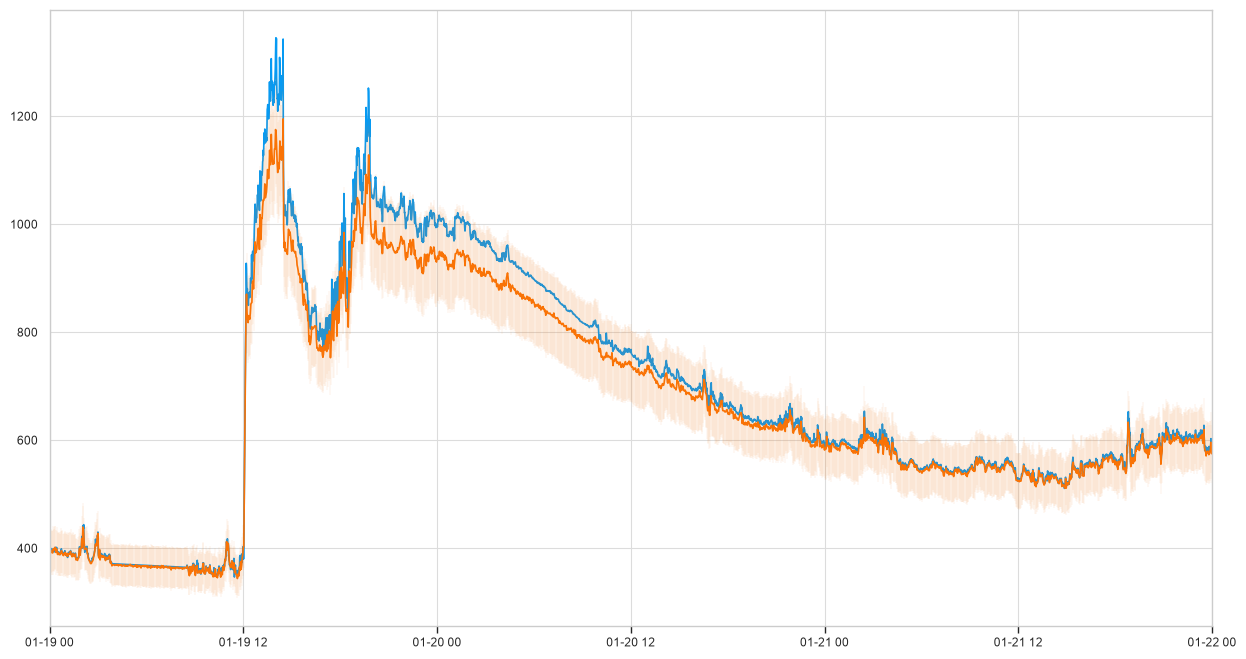

In [199]:
n_ensemble = 1000
cme_v_ensemble = np.zeros([len(solo_shifted.vt), n_ensemble])
ambient_wind = np.random.normal(params_opt.x[1],50,n_ensemble)
gamma = np.random.normal(params_opt.x[2],0.025,n_ensemble)
solo_speed = [np.random.normal(i,k, n_ensemble) for i,k in zip(solo_shifted.vt, solo_shifted.vt*0.1)]
           
vdrag_solo_ens = (solo_speed - ambient_wind) / (1. + (1. * (gamma * 1e-7) 
               * (solo_speed - ambient_wind) * solo_shifted.t_delta.iloc[0].total_seconds())) + ambient_wind


#vdrag_solo_ens_l1 = (solo_speed - ambient_wind) / (1. + (1. * (gamma * 1e-7) 
            #   * (solo_speed - ambient_wind) * solo_shifted_l1.t_delta[0].total_seconds())) + ambient_wind

vdrag_solo = np.mean(vdrag_solo_ens, axis=1)
#vdrag_solo_l1 = np.mean(vdrag_solo_ens_l1, axis=1)
print(len(vdrag_solo), vdrag_solo)

vdrag_solo_err = np.std(vdrag_solo_ens, axis=1)
#vdrag_solo_err_l1 = np.std(vdrag_solo_ens_l1, axis=1)


solo_shifted['vt_scaled'] = vdrag_solo
solo_shifted['vt_scaled_err'] = vdrag_solo_err


solo_shifted_flipped['vt_scaled'] = vdrag_solo
solo_shifted_flipped['vt_scaled_err'] = vdrag_solo_err

#solo_shifted_l1['vt_scaled'] = vdrag_solo_l1
#solo_shifted_l1['vt_scaled_err'] = vdrag_solo_err_l1

plt.figure(1,figsize=(15,8))
plt.plot(solo_input.time, solo_input.vt,color=c3)
plt.plot(solo_shifted.time, vdrag_solo,color=c2)
plt.errorbar(solo_shifted.time, vdrag_solo, yerr=vdrag_solo_err,alpha=0.05,color=c2)
plt.xlim(xlim_start, xlim_end)

In [200]:


solo_shifted_scaled = fia.scale_B_field_future(solo_shifted, l1_input_heeq, power=-1.57, power_upper=-1, power_lower=-2)
solo_shifted_scaled_flipped = fia.scale_B_field_future(solo_shifted_flipped, l1_input_heeq, power=-1.57, power_upper=-1, power_lower=-2)
#solo_shifted_scaled_l1 = fia.scale_B_field_future(solo_shifted_l1, l1_input, power=-1.57, power_upper=-1, power_lower=-2)



#mo_start_exp = datetime(2025,11,11,21,5)
#mo_end_exp = datetime(2025,11,12,20,3)

solo_shifted_scaled_exp = fia.expand_icme_future(solo_shifted_scaled, l1_input_heeq, mo_start_exp, mo_end_exp) # DEFINE END TIME
solo_shifted_scaled_exp_flipped = fia.expand_icme_future(solo_shifted_scaled_flipped, l1_input_heeq, mo_start_exp, mo_end_exp) # DEFINE END TIME


In [201]:
sc_exp = np.zeros(np.size(solo_shifted_scaled_exp.time_shifted_exp), dtype=[('time', object), ('np', float), ('np_err', float),
                                                   ('vt', float), ('vt_err', float), ('bx', float), ('by', float), 
                                                   ('bz', float), ('bt_err', float), ('bx_err', float), ('by_err', float),  ('bz_err', float), 
                                                   ('bt', float)])

sc_exp = sc_exp.view(np.recarray)

sc_exp.time = solo_shifted_scaled_exp.time_shifted_exp
sc_exp.np = solo_shifted_scaled_exp.np_scaled
sc_exp.np_err = solo_shifted_scaled_exp.np_scaled_err
sc_exp.vt = solo_shifted_scaled_exp.vt_scaled
sc_exp.vt_err = solo_shifted_scaled_exp.vt_scaled_err
sc_exp.bt = solo_shifted_scaled_exp.bt_scaled
sc_exp.bx = solo_shifted_scaled_exp.bx_scaled
sc_exp.by = solo_shifted_scaled_exp.by_scaled
sc_exp.bz = solo_shifted_scaled_exp.bz_scaled
sc_exp.bt_err = np.abs(solo_shifted_scaled_exp.bt_scaled_ub-solo_shifted_scaled_exp.bt_scaled_lb)
sc_exp.bx_err = np.abs(solo_shifted_scaled_exp.bx_scaled_ub-solo_shifted_scaled_exp.bx_scaled_lb)
sc_exp.by_err = np.abs(solo_shifted_scaled_exp.by_scaled_ub-solo_shifted_scaled_exp.by_scaled_lb)
sc_exp.bz_err = np.abs(solo_shifted_scaled_exp.bz_scaled_ub-solo_shifted_scaled_exp.bz_scaled_lb)


sc_exp_flipped = np.zeros(np.size(solo_shifted_scaled_exp_flipped.time_shifted_exp), dtype=[('time', object), ('np', float), ('np_err', float),
                                                   ('vt', float), ('vt_err', float), ('bx', float), ('by', float), 
                                                   ('bz', float), ('bt_err', float), ('bx_err', float), ('by_err', float),  ('bz_err', float), 
                                                   ('bt', float)])

sc_exp_flipped = sc_exp_flipped.view(np.recarray)

sc_exp_flipped.time = solo_shifted_scaled_exp_flipped.time_shifted_exp
sc_exp_flipped.np = solo_shifted_scaled_exp_flipped.np_scaled
sc_exp_flipped.np_err = solo_shifted_scaled_exp_flipped.np_scaled_err
sc_exp_flipped.vt = solo_shifted_scaled_exp_flipped.vt_scaled
sc_exp_flipped.vt_err = solo_shifted_scaled_exp_flipped.vt_scaled_err
sc_exp_flipped.bt = solo_shifted_scaled_exp_flipped.bt_scaled
sc_exp_flipped.bx = solo_shifted_scaled_exp_flipped.bx_scaled
sc_exp_flipped.by = solo_shifted_scaled_exp_flipped.by_scaled
sc_exp_flipped.bz = solo_shifted_scaled_exp_flipped.bz_scaled
sc_exp_flipped.bt_err = np.abs(solo_shifted_scaled_exp_flipped.bt_scaled_ub-solo_shifted_scaled_exp_flipped.bt_scaled_lb)
sc_exp_flipped.bx_err = np.abs(solo_shifted_scaled_exp_flipped.bx_scaled_ub-solo_shifted_scaled_exp_flipped.bx_scaled_lb)
sc_exp_flipped.by_err = np.abs(solo_shifted_scaled_exp_flipped.by_scaled_ub-solo_shifted_scaled_exp_flipped.by_scaled_lb)
sc_exp_flipped.bz_err = np.abs(solo_shifted_scaled_exp_flipped.bz_scaled_ub-solo_shifted_scaled_exp_flipped.bz_scaled_lb)


In [202]:
calc_l1 = False
if calc_l1:
    
    sc_exp_l1 = np.zeros(np.size(solo_shifted_scaled_exp_l1.time_shifted_exp), dtype=[('time', object), ('np', float), 
                                                       ('vt', float), ('bx', float), ('by', float), ('bz', float), 
                                                       ('bt', float)])
    
    sc_exp_l1 = sc_exp_l1.view(np.recarray)
    
    sc_exp_l1.time = solo_shifted_scaled_exp_l1.time_shifted_exp
    sc_exp_l1.np = solo_shifted_scaled_exp_l1.np_scaled
    sc_exp_l1.vt = solo_shifted_scaled_exp_l1.vt_scaled
    sc_exp_l1.bt = solo_shifted_scaled_exp_l1.bt_scaled
    sc_exp_l1.bx = solo_shifted_scaled_exp_l1.bx_scaled
    sc_exp_l1.by = solo_shifted_scaled_exp_l1.by_scaled
    sc_exp_l1.bz = solo_shifted_scaled_exp_l1.bz_scaled


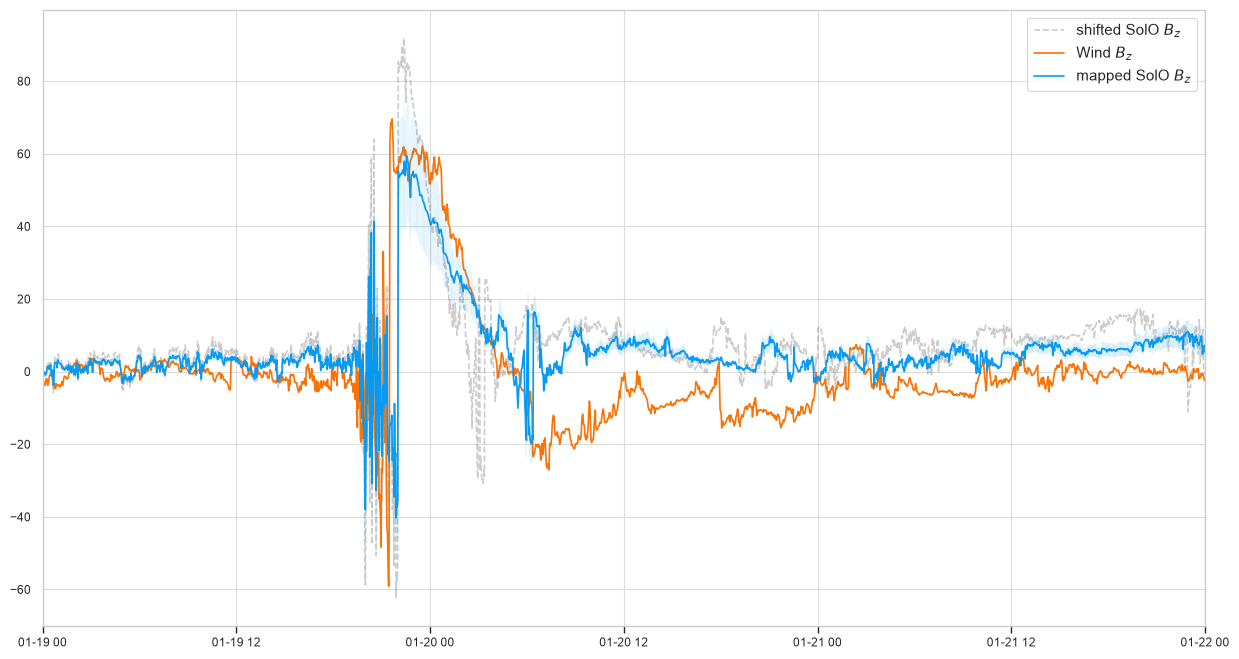

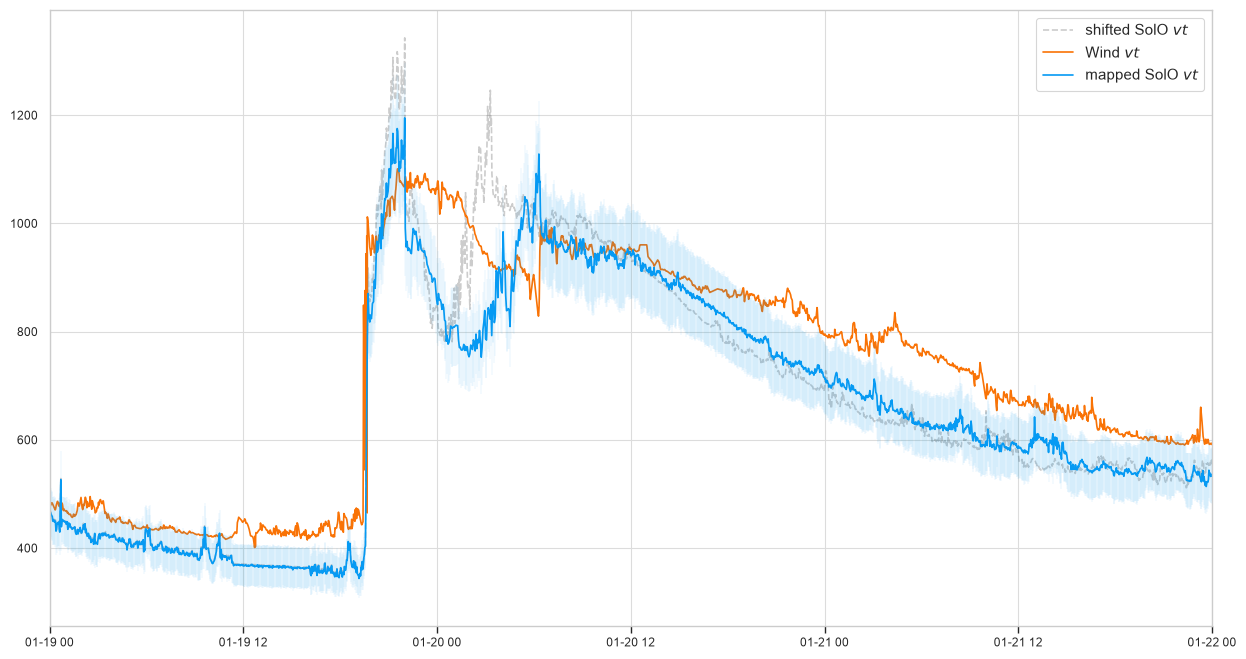

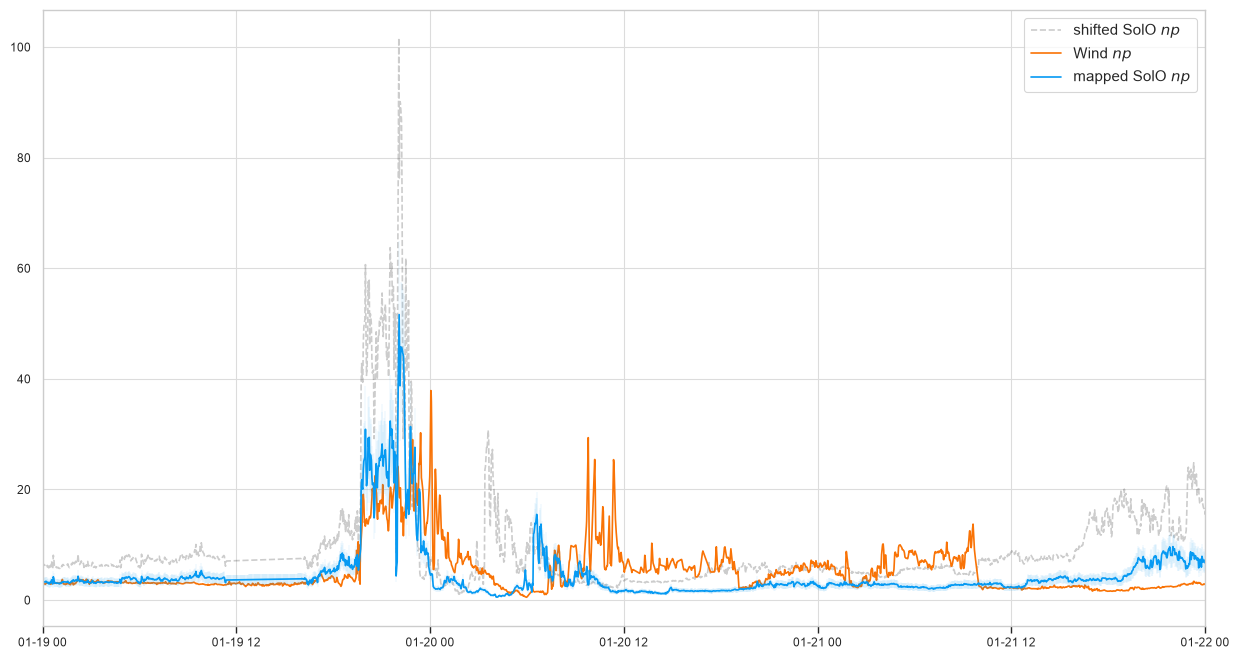

In [203]:
plt.figure(1, figsize=(15,8))
plt.plot(solo_shifted.time_shifted, solo_shifted.bz, c=c0, alpha=0.2, ls='--', label='shifted SolO $B_z$')
plt.plot(sc_0.time, sc_0.bz, c=c2, label=r'Wind $B_z$')
plt.plot(sc_exp.time, sc_exp.bz, c=c3, label=r'mapped SolO $B_z$')
plt.errorbar(sc_exp.time, sc_exp.bz, 
             yerr=np.abs(sc_exp.bz_err), color=c3, alpha=0.05)
plt.xlim(xlim_start, xlim_end)
plt.legend(fontsize=11)
#plt.savefig('figures/bz_scaled_exp_error.png')

plt.figure(2,figsize=(15,8))
plt.plot(solo_shifted.time_shifted, solo_shifted.vt, c=c0, alpha=0.2, ls='--', label='shifted SolO $vt$')
plt.plot(sc_0.time, sc_0.vt, c=c2, label=r'Wind $vt$')
plt.plot(sc_exp.time, sc_exp.vt, c=c3, label=r'mapped SolO $vt$')
plt.errorbar(sc_exp.time, sc_exp.vt, 
             yerr=np.abs(sc_exp.vt_err), color=c3, alpha=0.05)
plt.xlim(xlim_start, xlim_end)
plt.legend(fontsize=11)
#plt.savefig('figures/vt_scaled_exp_error.png')

plt.figure(3,figsize=(15,8))
plt.plot(solo_shifted.time_shifted, solo_shifted.np, c=c0, alpha=0.2, ls='--', label='shifted SolO $np$')
plt.plot(sc_0.time, sc_0.np, c=c2, label=r'Wind $np$')
plt.plot(sc_exp.time, sc_exp.np, c=c3, label=r'mapped SolO $np$')
plt.errorbar(sc_exp.time, sc_exp.np, 
             yerr=np.abs(sc_exp.np_err), color=c3, alpha=0.05)
plt.xlim(xlim_start, xlim_end)
plt.legend(fontsize=11)
#plt.savefig('figures/np_scaled_exp_error.png')

In [205]:
sc_1 = sc_exp
sc_1_flipped = sc_exp_flipped

In [207]:
sc_1 = pd.DataFrame(sc_exp)
sc_1_min = pd.DataFrame(sc_exp)

#solo.time = [sc_1.time[i]+timedelta(seconds=delta_t_l1[i].astype(float)) for i in range(len(delta_t_l1))]

# Assume the time column is named 'time'
sc_1['time'] = pd.to_datetime(sc_1['time'])
sc_1 = sc_1.set_index('time').sort_index()
sc_1 = sc_1[~sc_1.index.duplicated(keep="first")]
sc_1 = (sc_1.resample('1min').interpolate(method='time'))

sc_1_min['time'] = pd.to_datetime(sc_1_min['time'])
sc_1_min = sc_1_min.set_index('time').sort_index()
#sc_1_min = sc_0_min[~sc_0_min.index.duplicated(keep="first")]
sc_1_min = (sc_1_min.resample('1min').interpolate(method='time'))
sc_1_min = sc_1_min.dropna()
print(sc_1_min)


# Average into 1-hour bins
sc_1_hour = sc_1.resample('1h').mean()

sc_1 = sc_1.reset_index()
sc_1_min = sc_1_min.reset_index()
sc_1_hour = sc_1_hour.reset_index()

                           np    np_err          vt     vt_err        bx  \
time                                                                       
2026-01-18 19:34:00  3.940197  0.965638  522.129243  49.545471 -4.386154   
2026-01-18 19:35:00  3.975251  0.974256  521.426811  50.247257 -4.587041   
2026-01-18 19:36:00  4.010305  0.982875  520.724379  50.949044 -4.787927   
2026-01-18 19:37:00  4.045356  0.991493  521.740836  51.208097 -4.697478   
2026-01-18 19:38:00  4.080408  1.000112  522.757294  51.467150 -4.607028   
...                       ...       ...         ...        ...       ...   
2026-01-22 14:56:00  3.955724  1.123844  560.907440  53.305472 -7.106624   
2026-01-22 14:57:00  3.926346  1.115528  560.710522  53.229235 -7.155238   
2026-01-22 14:58:00  3.839791  1.090966  559.671787  53.230594 -7.203850   
2026-01-22 14:59:00  3.703370  1.052235  555.531532  52.918735 -7.245390   
2026-01-22 15:00:00  3.518990  0.999875  548.408393  52.305640 -7.280130   

           

In [208]:
sc_1_flipped = pd.DataFrame(sc_exp_flipped)
sc_1_min_flipped = pd.DataFrame(sc_exp_flipped)

#solo.time = [sc_1.time[i]+timedelta(seconds=delta_t_l1[i].astype(float)) for i in range(len(delta_t_l1))]

# Assume the time column is named 'time'
sc_1_flipped['time'] = pd.to_datetime(sc_1_flipped['time'])
sc_1_flipped = sc_1_flipped.set_index('time').sort_index()
sc_1_flipped = sc_1_flipped[~sc_1_flipped.index.duplicated(keep="first")]
sc_1_flipped = (sc_1_flipped.resample('1min').interpolate(method='time'))

sc_1_min_flipped['time'] = pd.to_datetime(sc_1_min_flipped['time'])
sc_1_min_flipped = sc_1_min_flipped.set_index('time').sort_index()
#sc_1_min = sc_0_min[~sc_0_min.index.duplicated(keep="first")]
sc_1_min_flipped = (sc_1_min_flipped.resample('1min').interpolate(method='time'))
sc_1_min_flipped = sc_1_min_flipped.dropna()
print(sc_1_min_flipped)


# Average into 1-hour bins
sc_1_hour_flipped = sc_1_flipped.resample('1h').mean()

sc_1_flipped = sc_1_flipped.reset_index()
sc_1_min_flipped = sc_1_min_flipped.reset_index()
sc_1_hour_flipped = sc_1_hour_flipped.reset_index()

                           np    np_err          vt     vt_err        bx  \
time                                                                       
2026-01-18 19:34:00  3.940197  0.965638  522.129243  49.545471 -4.386154   
2026-01-18 19:35:00  3.975251  0.974256  521.426811  50.247257 -4.587041   
2026-01-18 19:36:00  4.010305  0.982875  520.724379  50.949044 -4.787927   
2026-01-18 19:37:00  4.045356  0.991493  521.740836  51.208097 -4.697478   
2026-01-18 19:38:00  4.080408  1.000112  522.757294  51.467150 -4.607028   
...                       ...       ...         ...        ...       ...   
2026-01-22 14:56:00  3.955724  1.123844  560.907440  53.305472 -7.106624   
2026-01-22 14:57:00  3.926346  1.115528  560.710522  53.229235 -7.155238   
2026-01-22 14:58:00  3.839791  1.090966  559.671787  53.230594 -7.203850   
2026-01-22 14:59:00  3.703370  1.052235  555.531532  52.918735 -7.245390   
2026-01-22 15:00:00  3.518990  0.999875  548.408393  52.305640 -7.280130   

           

In [209]:
Pdyn_hour_solo, Ey_hour_solo, Dst_hour_solo, rand_params_solo = calc_pennati(sc_1_hour, n_ens=10000,sc_name='Wind')

In [210]:
Pdyn_hour_solo_flipped, Ey_hour_solo_flipped, Dst_hour_solo_flipped, rand_params_solo_flipped = calc_pennati(sc_1_hour_flipped, n_ens=10000,sc_name='Wind')

In [211]:

if calc_symh:
    sc_1_min = sc_1_min.interpolate()
    sc_1_min_rec = sc_1_min.to_records()
    print(sc_1_min_rec)
    
    symh_solo = predict.calc_dst_temerin_li(mdates.date2num(sc_1_min_rec.time), sc_1_min_rec.bt, sc_1_min_rec.bx, 
                                                       sc_1_min_rec.by, sc_1_min_rec.bz, sc_1_min_rec.vt, sc_1_min_rec.vt, 
                                                       sc_1_min_rec.np, dst1=-10, dst2=-6, dst3=-8, version='2006', linear_t_correction=True, minute_res=True)

[(   0, '2026-01-18T19:34:00.000000', 3.94019739, 0.96563816, 522.12924251, 49.54547076, -4.38615378, 3.93182695,  1.43855762, 1.64780564, 1.1919565 , 1.06849119, 0.39093433, 6.06358448)
 (   1, '2026-01-18T19:35:00.000000', 3.97525124, 0.97425645, 521.42681067, 50.24725726, -4.58704054, 3.76959464,  1.45439507, 1.66264249, 1.24658497, 1.02443144, 0.39524947, 6.11800737)
 (   2, '2026-01-18T19:36:00.000000', 4.01030509, 0.98287474, 520.72437883, 50.94904375, -4.78792729, 3.60736234,  1.47023252, 1.67747935, 1.30121343, 0.98037168, 0.39956461, 6.17243025)
 ...
 (5484, '2026-01-22T14:58:00.000000', 3.83979113, 1.09096641, 559.671787  , 53.23059389, -7.20384985, 1.98616067, -0.31073516, 2.36989158, 2.27236831, 0.62650934, 0.09801766, 7.51301907)
 (5485, '2026-01-22T14:59:00.000000', 3.70336992, 1.05223486, 555.53153216, 52.91873521, -7.2453903 , 1.73429247,  0.20251965, 2.37430515, 2.28553584, 0.54707498, 0.20921382, 7.52679815)
 (5486, '2026-01-22T15:00:00.000000', 3.51898994, 0.99987491

In [212]:
if calc_symh:
    sc_1_min_flipped = sc_1_min_flipped.interpolate()
    sc_1_min_rec_flipped = sc_1_min_flipped.to_records()
    print(sc_1_min_rec_flipped)
    
    symh_solo_flipped = predict.calc_dst_temerin_li(mdates.date2num(sc_1_min_rec_flipped.time), sc_1_min_rec_flipped.bt, sc_1_min_rec_flipped.bx, 
                                                       sc_1_min_rec_flipped.by, sc_1_min_rec_flipped.bz, sc_1_min_rec_flipped.vt, sc_1_min_rec_flipped.vt, 
                                                       sc_1_min_rec_flipped.np, dst1=-10, dst2=-6, dst3=-8, version='2006', linear_t_correction=True, minute_res=True)

[(   0, '2026-01-18T19:34:00.000000', 3.94019739, 0.96563816, 522.12924251, 49.54547076, -4.38615378, 3.93182695,  1.43855762, 1.64780564, 1.1919565 , 1.06849119, 0.39093433, 6.06358448)
 (   1, '2026-01-18T19:35:00.000000', 3.97525124, 0.97425645, 521.42681067, 50.24725726, -4.58704054, 3.76959464,  1.45439507, 1.66264249, 1.24658497, 1.02443144, 0.39524947, 6.11800737)
 (   2, '2026-01-18T19:36:00.000000', 4.01030509, 0.98287474, 520.72437883, 50.94904375, -4.78792729, 3.60736234,  1.47023252, 1.67747935, 1.30121343, 0.98037168, 0.39956461, 6.17243025)
 ...
 (5484, '2026-01-22T14:58:00.000000', 3.83979113, 1.09096641, 559.671787  , 53.23059389, -7.20384985, 1.98616067, -0.31073516, 2.36989158, 2.27236831, 0.62650934, 0.09801766, 7.51301907)
 (5485, '2026-01-22T14:59:00.000000', 3.70336992, 1.05223486, 555.53153216, 52.91873521, -7.2453903 , 1.73429247,  0.20251965, 2.37430515, 2.28553584, 0.54707498, 0.20921382, 7.52679815)
 (5486, '2026-01-22T15:00:00.000000', 3.51898994, 0.99987491

In [213]:
[omni_input, omni_header]=pickle.load(open(data_path+'omni_high_res_2026.p', 'rb'))

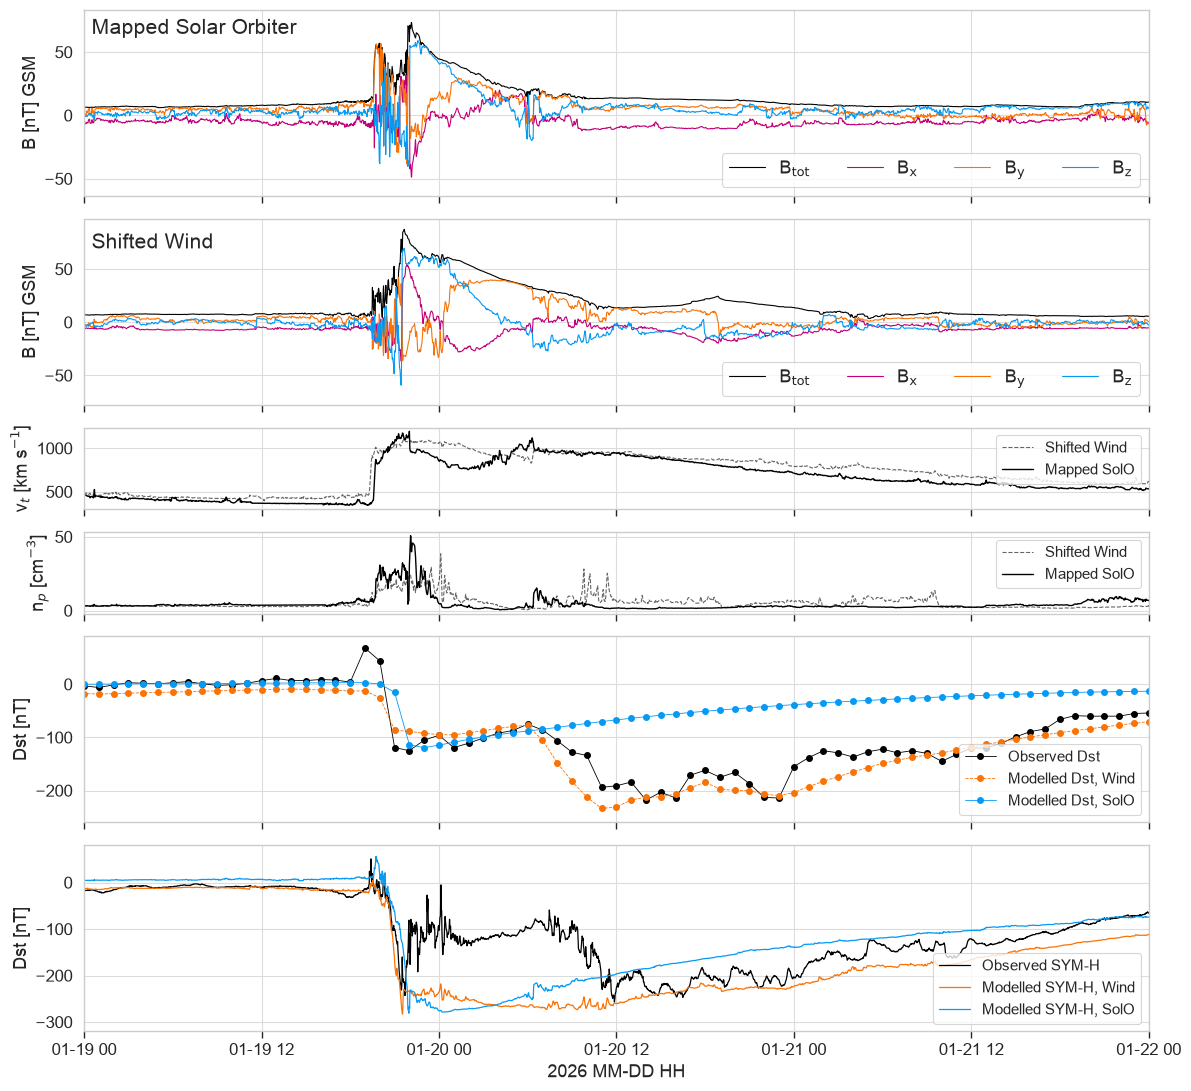

In [252]:
fontsize=13

#print(np.round(np.min(sc_0['dst']),1), np.round(sc_0['dst_err_max'][sc_0['dst']==np.min(sc_0['dst'])]-sc_0['dst_err_min'][sc_0['dst']==np.min(sc_0['dst'])],1)[0])

c0 = "xkcd:black"
c1 = "xkcd:magenta"
c2 = "xkcd:orange"
c3 = "xkcd:azure"

#fig, (ax4, ax6,ax5) = plt.subplots(3, 1, figsize=(12,8), sharex=True)

fig = plt.figure(1, figsize=(12,11))

ax2 = plt.subplot2grid((10,1), (0,0), rowspan=2)
#ax2.plot([mo_start_earth,mo_start_earth], [-100,200], c=c0, ls='--', lw=0.8)
#ax2.plot([mo_end_earth,mo_end_earth], [-100,200], c=c0, ls='--', lw=0.8)
ax2.plot(sc_1['time'], sc_1['bt'], label=r'B$_{\mathrm{tot}}$', c=c0, lw=0.8)
ax2.plot(sc_1['time'], sc_1['bx'], label=r'B$_{\mathrm{x}}$', c=c1, lw=0.8)
ax2.plot(sc_1['time'], sc_1['by'], label=r'B$_{\mathrm{y}}$', c=c2, lw=0.8)
ax2.plot(sc_1['time'], sc_1['bz'], label=r'B$_{\mathrm{z}}$', c=c3, lw=0.8)

#ax2.fill_between(sc_1['time'], y1= sc_1['bt']- sc_1['bt_err'], y2= sc_1['bt'] + sc_1['bt_err'], color=c0, alpha=0.2)
#ax2.fill_between(sc_1['time'], y1= sc_1['bx']- sc_1['bx_err'], y2= sc_1['bx'] + sc_1['bx_err'], color=c1, alpha=0.2)
#ax2.fill_between(sc_1['time'], y1= sc_1['by']- sc_1['by_err'], y2= sc_1['by'] + sc_1['by_err'], color=c2, alpha=0.2)
#ax2.fill_between(sc_1['time'], y1= sc_1['bz']- sc_1['bz_err'], y2= sc_1['bz'] + sc_1['bz_err'], color=c3, alpha=0.2)

#ax2.plot(sc_1_hour['time'], sc_1_hour['bt'], c=c0, marker='o', ms=4, ls=' ')
#ax2.plot(sc_1_hour['time'], sc_1_hour['bx'], c=c1, marker='o', ms=4, ls=' ')
#ax2.plot(sc_1_hour['time'], sc_1_hour['by'], c=c2, marker='o', ms=4, ls=' ')
#ax2.plot(sc_1_hour['time'], sc_1_hour['bz'], c=c3, marker='o', ms=4, ls=' ')
ax2.tick_params(axis='x', labelbottom='off')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=12)
ax2.set_ylabel('B [nT] GSM', fontsize=13)
ax2.set_xlim(xlim_start, xlim_end)
ax2.set_ylim(-np.max(sc_1.bt)+10.,np.max(sc_1.bt)+10.)
ax2.legend(loc='lower right', ncol=4, fontsize=13)


ax1 = plt.subplot2grid((10,1), (2,0), rowspan=2)
#ax1.plot([mo_start_earth,mo_start_earth], [-100,200], c=c0, ls='--', lw=0.8)
#ax1.plot([mo_end_earth,mo_end_earth], [-100,200], c=c0, ls='--', lw=0.8)
ax1.plot(sc_0['time'], sc_0['bt'], label=r'B$_{\mathrm{tot}}$', c=c0, lw=0.8)
ax1.plot(sc_0['time'], sc_0['bx'], label=r'B$_{\mathrm{x}}$', c=c1, lw=0.8)
ax1.plot(sc_0['time'], sc_0['by'], label=r'B$_{\mathrm{y}}$', c=c2, lw=0.8)
ax1.plot(sc_0['time'], sc_0['bz'], label=r'B$_{\mathrm{z}}$', c=c3, lw=0.8)

#ax1.plot(sc_0_hour['time'], sc_0_hour['bt'], c=c0, marker='o', ms=4, ls=' ')
#ax1.plot(sc_0_hour['time'], sc_0_hour['bx'], c=c1, marker='o', ms=4, ls=' ')
#ax1.plot(sc_0_hour['time'], sc_0_hour['by'], c=c2, marker='o', ms=4, ls=' ')
#ax1.plot(sc_0_hour['time'], sc_0_hour['bz'], c=c3, marker='o', ms=4, ls=' ')
ax1.tick_params(axis='x', labelbottom='off')
ax1.set_xticklabels([])
ax1.tick_params(axis='y', labelsize=12)
ax1.set_ylabel('B [nT] GSM', fontsize=13)
ax1.set_xlim(xlim_start, xlim_end)
ax1.set_ylim(-np.max(sc_0.bt)+10.,np.max(sc_0.bt)+10.)
ax1.legend(loc='lower right', ncol=4, fontsize=13)


ax6=plt.subplot2grid((10,1), (4,0), rowspan=1)
ax6.plot(sc_0_min['time'], sc_0_min.vt, label=r'Shifted Wind', c=c0, ls='--', lw=0.8, alpha=0.6)
ax6.plot(sc_1_min['time'], sc_1_min.vt, label=r'Mapped SolO', c=c0, ls='-', lw=1)
ax6.set_ylabel(r'v$_t$ [km s$^{-1}$]', fontsize=fontsize)
ax6.set_xticklabels([])
ax6.tick_params(axis='x', labelbottom='off')
ax6.tick_params(axis='y', labelsize=12)
ax6.legend(loc='upper right', fontsize=fontsize-2)
ax6.set_xlim(xlim_start, xlim_end)


ax4=plt.subplot2grid((10,1), (5,0), rowspan=1)
ax4.plot(sc_0_min['time'], sc_0_min.np, label=r'Shifted Wind', c=c0, ls='--', lw=0.8, alpha=0.6)
ax4.plot(sc_1_min['time'], sc_1_min.np, label=r'Mapped SolO', c=c0, ls='-', lw=1)
#ax4.fill_between(sc_0['time'], y1=np.mean(Ey_min,axis=0)-np.std(Ey_min,axis=0), y2=np.mean(Ey_min,axis=0)+np.std(Ey_min,axis=0), color=c0, alpha=0.1)
ax4.set_ylabel(r'n$_p$ [cm$^{-3}$]', fontsize=fontsize)
ax4.set_xticklabels([])
ax4.tick_params(axis='x', labelbottom='off')
ax4.tick_params(axis='y', labelsize=12)
ax4.legend(loc='upper right', fontsize=fontsize-2)
ax4.set_xlim(xlim_start, xlim_end)
#ax4.set_ylim(0,55)


ax5=plt.subplot2grid((10,1), (6,0), rowspan=2)
#ax5.plot(omni_input.time, omni_input.symh, c=c0, alpha=0.3, lw=0.6, label='SYM-H (obs.)')
ax5.plot(df_dst.time, df_dst.dst, marker='o', ms=4, c=c0, lw=0.6, label='Observed Dst')
ax5.plot(sc_0_hour.time, Dst_hour, marker='o', ms=4, c=c2, lw=0.6, ls='--', label='Modelled Dst, Wind')
ax5.plot(sc_1_hour.time, Dst_hour_solo, marker='o', ms=4, c=c3, lw=0.6, label='Modelled Dst, SolO')
ax5.set_xticklabels([])
ax5.tick_params(axis='x', labelbottom='off')
ax5.tick_params(axis='y', labelsize=12)
#ax5.set_xlabel('2026 MM-DD HH', fontsize=13)
ax5.set_ylabel('Dst [nT]', fontsize=13)
ax5.legend(loc='lower right', fontsize=11)
ax5.set_xlim(xlim_start, xlim_end)
ax5.set_ylim(-260,90)


ax3=plt.subplot2grid((10,1), (8,0), rowspan=2)
#ax5.plot(omni_input.time, omni_input.symh, c=c0, alpha=0.3, lw=0.6, label='SYM-H (obs.)')
ax3.plot(omni_input.time, omni_input.symh, c=c0, lw=0.9, label='Observed SYM-H')
ax3.plot(sc_0_min_rec.time, symh, c=c2, lw=0.9, ls='-', label='Modelled SYM-H, Wind')
ax3.plot(sc_1_min_rec.time, symh_solo, c=c3, lw=0.9, label='Modelled SYM-H, SolO')
ax3.tick_params(axis='x', labelsize=12)
ax3.tick_params(axis='y', labelsize=12)
ax3.set_xlabel('2026 MM-DD HH', fontsize=13)
ax3.set_ylabel('Dst [nT]', fontsize=13)
ax3.legend(loc='lower right', fontsize=11)
ax3.set_xlim(xlim_start, xlim_end)
ax3.set_ylim(-320,80)


#ax6.plot(mdates.num2date(sc_1_dst['time']), sc_1_dst['dst'], label='Dst (calc)', c=c2)
#ax6.fill_between(mdates.num2date(sc_1_dst['time']), y1=sc_1_dst['dst_err_min'], y2=sc_1_dst['dst_err_max'], color=c2, alpha=0.4)
#ax6.set_ylabel('Dst [nT]', fontsize=fontsize)

#ax6.legend(loc='lower left', fontsize=fontsize-2)
#plt.xlim(sc_1['time'][-2000],sc_1['time'][-1])
#plt.xlim(datetime(2026,1,19), datetime(2026,1,21,12))

#plt.figtext(0.01,0.97, 'a)', fontsize=15)
#plt.figtext(0.01,0.81, 'b)', fontsize=15)
#plt.figtext(0.01,0.65, 'c)', fontsize=15)
#plt.figtext(0.01,0.49, 'd)', fontsize=15)
#plt.figtext(0.01,0.33, 'e)', fontsize=15)
plt.figtext(0.08,0.965, 'Mapped Solar Orbiter', fontsize=15)
plt.figtext(0.08,0.77, 'Shifted Wind', fontsize=15)
#plt.figtext(0.01,0.40, 'd)', fontsize=15)
#plt.figtext(0.01,0.21, 'e)', fontsize=15)

fig.tight_layout()
plt.savefig('figures/cospar/2026jan19_dst_symh.png')
#plt.close()
plt.show()

In [246]:
print('Min Dst, Wind: ', np.round(np.min(Dst_hour_flipped),1))
print('Min Dst, SolO: ', np.round(np.min(Dst_hour_solo_flipped),1))
print(np.min(symh_flipped))
print(np.min(symh_solo_flipped))

Min Dst, Wind:  -825.9
Min Dst, SolO:  -497.2
-1077.0775456863535
-883.8562411333864


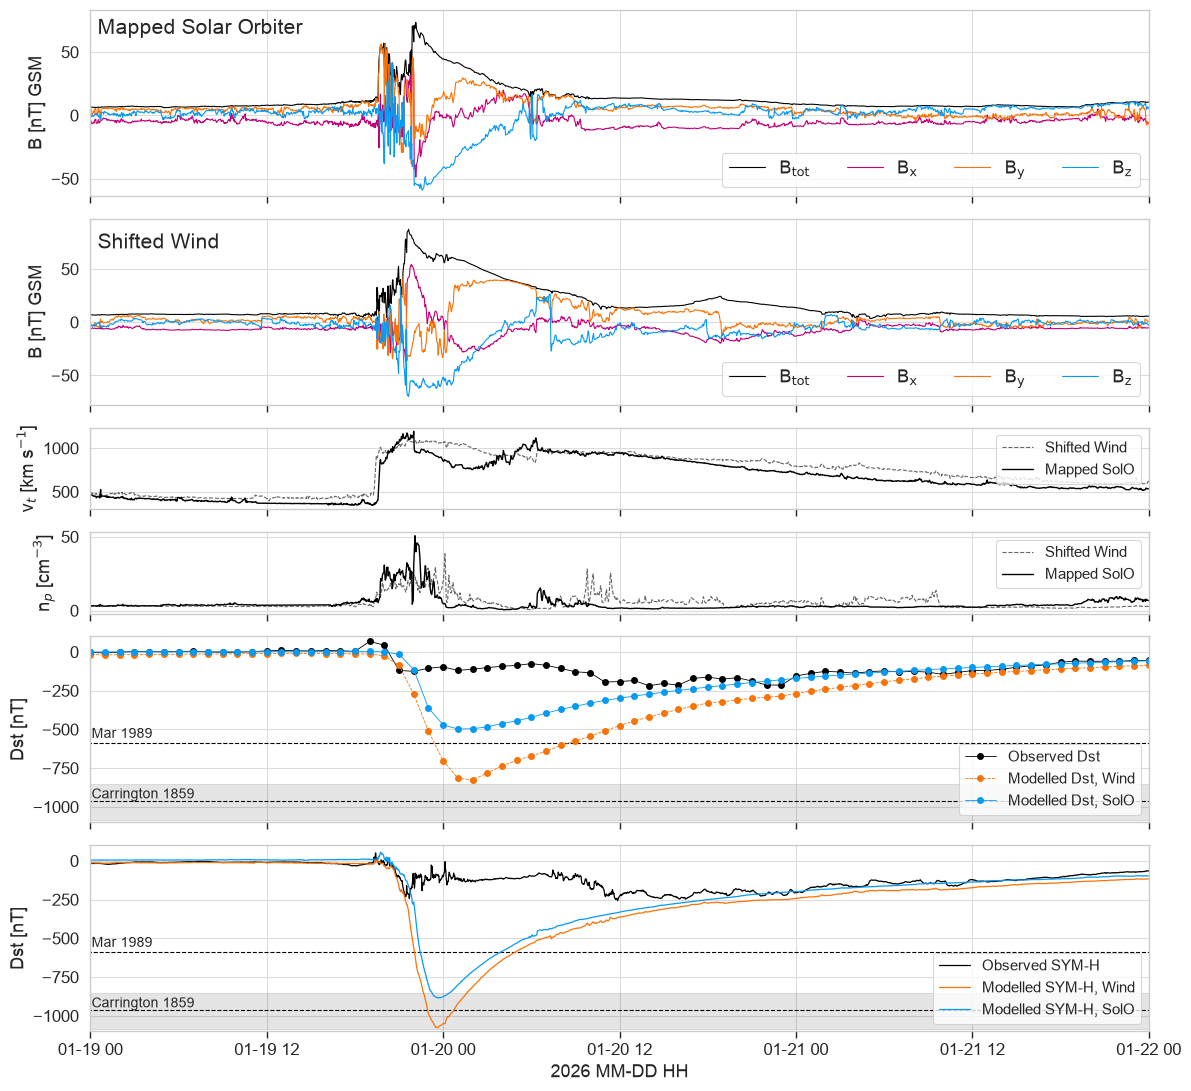

In [241]:
fontsize=13

#print(np.round(np.min(sc_0['dst']),1), np.round(sc_0['dst_err_max'][sc_0['dst']==np.min(sc_0['dst'])]-sc_0['dst_err_min'][sc_0['dst']==np.min(sc_0['dst'])],1)[0])

c0 = "xkcd:black"
c1 = "xkcd:magenta"
c2 = "xkcd:orange"
c3 = "xkcd:azure"

#fig, (ax4, ax6,ax5) = plt.subplots(3, 1, figsize=(12,8), sharex=True)

fig = plt.figure(1, figsize=(12,11))

ax2 = plt.subplot2grid((10,1), (0,0), rowspan=2)
#ax2.plot([mo_start_earth,mo_start_earth], [-100,200], c=c0, ls='--', lw=0.8)
#ax2.plot([mo_end_earth,mo_end_earth], [-100,200], c=c0, ls='--', lw=0.8)
ax2.plot(sc_1_flipped['time'], sc_1_flipped['bt'], label=r'B$_{\mathrm{tot}}$', c=c0, lw=0.8)
ax2.plot(sc_1_flipped['time'], sc_1_flipped['bx'], label=r'B$_{\mathrm{x}}$', c=c1, lw=0.8)
ax2.plot(sc_1_flipped['time'], sc_1_flipped['by'], label=r'B$_{\mathrm{y}}$', c=c2, lw=0.8)
ax2.plot(sc_1_flipped['time'], sc_1_flipped['bz'], label=r'B$_{\mathrm{z}}$', c=c3, lw=0.8)

#ax2.fill_between(sc_1['time'], y1= sc_1['bt']- sc_1['bt_err'], y2= sc_1['bt'] + sc_1['bt_err'], color=c0, alpha=0.2)
#ax2.fill_between(sc_1['time'], y1= sc_1['bx']- sc_1['bx_err'], y2= sc_1['bx'] + sc_1['bx_err'], color=c1, alpha=0.2)
#ax2.fill_between(sc_1['time'], y1= sc_1['by']- sc_1['by_err'], y2= sc_1['by'] + sc_1['by_err'], color=c2, alpha=0.2)
#ax2.fill_between(sc_1['time'], y1= sc_1['bz']- sc_1['bz_err'], y2= sc_1['bz'] + sc_1['bz_err'], color=c3, alpha=0.2)

#ax2.plot(sc_1_hour['time'], sc_1_hour['bt'], c=c0, marker='o', ms=4, ls=' ')
#ax2.plot(sc_1_hour['time'], sc_1_hour['bx'], c=c1, marker='o', ms=4, ls=' ')
#ax2.plot(sc_1_hour['time'], sc_1_hour['by'], c=c2, marker='o', ms=4, ls=' ')
#ax2.plot(sc_1_hour['time'], sc_1_hour['bz'], c=c3, marker='o', ms=4, ls=' ')
ax2.tick_params(axis='x', labelbottom='off')
ax2.set_xticklabels([])
ax2.tick_params(axis='y', labelsize=12)
ax2.set_ylabel('B [nT] GSM', fontsize=13)
ax2.set_xlim(xlim_start, xlim_end)
ax2.set_ylim(-np.max(sc_1.bt)+10.,np.max(sc_1.bt)+10.)
ax2.legend(loc='lower right', ncol=4, fontsize=13)


ax1 = plt.subplot2grid((10,1), (2,0), rowspan=2)
#ax1.plot([mo_start_earth,mo_start_earth], [-100,200], c=c0, ls='--', lw=0.8)
#ax1.plot([mo_end_earth,mo_end_earth], [-100,200], c=c0, ls='--', lw=0.8)
ax1.plot(sc_0_flipped['time'], sc_0_flipped['bt'], label=r'B$_{\mathrm{tot}}$', c=c0, lw=0.8)
ax1.plot(sc_0_flipped['time'], sc_0_flipped['bx'], label=r'B$_{\mathrm{x}}$', c=c1, lw=0.8)
ax1.plot(sc_0_flipped['time'], sc_0_flipped['by'], label=r'B$_{\mathrm{y}}$', c=c2, lw=0.8)
ax1.plot(sc_0_flipped['time'], sc_0_flipped['bz'], label=r'B$_{\mathrm{z}}$', c=c3, lw=0.8)

#ax1.plot(sc_0_hour['time'], sc_0_hour['bt'], c=c0, marker='o', ms=4, ls=' ')
#ax1.plot(sc_0_hour['time'], sc_0_hour['bx'], c=c1, marker='o', ms=4, ls=' ')
#ax1.plot(sc_0_hour['time'], sc_0_hour['by'], c=c2, marker='o', ms=4, ls=' ')
#ax1.plot(sc_0_hour['time'], sc_0_hour['bz'], c=c3, marker='o', ms=4, ls=' ')
ax1.tick_params(axis='x', labelbottom='off')
ax1.set_xticklabels([])
ax1.tick_params(axis='y', labelsize=12)
ax1.set_ylabel('B [nT] GSM', fontsize=13)
ax1.set_xlim(xlim_start, xlim_end)
ax1.set_ylim(-np.max(sc_0.bt)+10.,np.max(sc_0.bt)+10.)
ax1.legend(loc='lower right', ncol=4, fontsize=13)


ax6=plt.subplot2grid((10,1), (4,0), rowspan=1)
ax6.plot(sc_0_min_flipped['time'], sc_0_min_flipped.vt, label=r'Shifted Wind', c=c0, ls='--', lw=0.8, alpha=0.6)
ax6.plot(sc_1_min_flipped['time'], sc_1_min_flipped.vt, label=r'Mapped SolO', c=c0, ls='-', lw=1)
ax6.set_ylabel(r'v$_t$ [km s$^{-1}$]', fontsize=fontsize)
ax6.set_xticklabels([])
ax6.tick_params(axis='x', labelbottom='off')
ax6.tick_params(axis='y', labelsize=12)
ax6.legend(loc='upper right', fontsize=fontsize-2)
ax6.set_xlim(xlim_start, xlim_end)


ax4=plt.subplot2grid((10,1), (5,0), rowspan=1)
ax4.plot(sc_0_min_flipped['time'], sc_0_min_flipped.np, label=r'Shifted Wind', c=c0, ls='--', lw=0.8, alpha=0.6)
ax4.plot(sc_1_min_flipped['time'], sc_1_min_flipped.np, label=r'Mapped SolO', c=c0, ls='-', lw=1)
#ax4.fill_between(sc_0['time'], y1=np.mean(Ey_min,axis=0)-np.std(Ey_min,axis=0), y2=np.mean(Ey_min,axis=0)+np.std(Ey_min,axis=0), color=c0, alpha=0.1)
ax4.set_ylabel(r'n$_p$ [cm$^{-3}$]', fontsize=fontsize)
ax4.set_xticklabels([])
ax4.tick_params(axis='x', labelbottom='off')
ax4.tick_params(axis='y', labelsize=12)
ax4.legend(loc='upper right', fontsize=fontsize-2)
ax4.set_xlim(xlim_start, xlim_end)
#ax4.set_ylim(0,55)


ax5=plt.subplot2grid((10,1), (6,0), rowspan=2)
#ax5.plot(omni_input.time, omni_input.symh, c=c0, alpha=0.3, lw=0.6, label='SYM-H (obs.)')
ax5.plot([sc_0_hour.time.loc[0],sc_0_hour.time.iloc[-1]], [-589,-589], 'k--', lw=0.8)
ax5.plot([sc_0_hour.time.loc[0],sc_0_hour.time.iloc[-1]], [-964,-964], 'k--', lw=0.8)
ax5.fill_between(sc_0_hour.time, y1=-855, y2=-1087, color=c0, alpha=0.1) #855, 1087
ax5.plot(df_dst.time, df_dst.dst, marker='o', ms=4, c=c0, lw=0.6, label='Observed Dst')
ax5.plot(sc_0_hour_flipped.time, Dst_hour_flipped, marker='o', ms=4, c=c2, lw=0.6, ls='--', label='Modelled Dst, Wind')
ax5.plot(sc_1_hour_flipped.time, Dst_hour_solo_flipped, marker='o', ms=4, c=c3, lw=0.6, label='Modelled Dst, SolO')
ax5.set_xticklabels([])
ax5.tick_params(axis='x', labelbottom='off')
ax5.tick_params(axis='y', labelsize=12)
#ax5.set_xlabel('2026 MM-DD HH', fontsize=13)
ax5.set_ylabel('Dst [nT]', fontsize=13)
ax5.legend(loc='lower right', fontsize=11)
ax5.set_xlim(xlim_start, xlim_end)
ax5.set_ylim(-1100,100)


ax3=plt.subplot2grid((10,1), (8,0), rowspan=2)
#ax5.plot(omni_input.time, omni_input.symh, c=c0, alpha=0.3, lw=0.6, label='SYM-H (obs.)')
ax3.plot([sc_0_hour.time.loc[0],sc_0_hour.time.iloc[-1]], [-589,-589], 'k--', lw=0.8)
ax3.plot([sc_0_hour.time.loc[0],sc_0_hour.time.iloc[-1]], [-964,-964], 'k--', lw=0.8)
ax3.fill_between(sc_0_hour.time, y1=-855, y2=-1087, color=c0, alpha=0.1) #855, 1087
ax3.plot(omni_input.time, omni_input.symh, c=c0, lw=0.9, label='Observed SYM-H')
ax3.plot(sc_0_min_rec_flipped.time, symh_flipped, c=c2, lw=0.9, ls='-', label='Modelled SYM-H, Wind')
ax3.plot(sc_1_min_rec_flipped.time, symh_solo_flipped, c=c3, lw=0.9, label='Modelled SYM-H, SolO')
ax3.tick_params(axis='x', labelsize=12)
ax3.tick_params(axis='y', labelsize=12)
ax3.set_xlabel('2026 MM-DD HH', fontsize=13)
ax3.set_ylabel('Dst [nT]', fontsize=13)
ax3.legend(loc='lower right', fontsize=11)
ax3.set_xlim(xlim_start, xlim_end)
ax3.set_ylim(-1100,100)


#ax6.plot(mdates.num2date(sc_1_dst['time']), sc_1_dst['dst'], label='Dst (calc)', c=c2)
#ax6.fill_between(mdates.num2date(sc_1_dst['time']), y1=sc_1_dst['dst_err_min'], y2=sc_1_dst['dst_err_max'], color=c2, alpha=0.4)
#ax6.set_ylabel('Dst [nT]', fontsize=fontsize)

#ax6.legend(loc='lower left', fontsize=fontsize-2)
#plt.xlim(sc_1['time'][-2000],sc_1['time'][-1])
#plt.xlim(datetime(2026,1,19), datetime(2026,1,21,12))

#plt.figtext(0.01,0.97, 'a)', fontsize=15)
#plt.figtext(0.01,0.81, 'b)', fontsize=15)
#plt.figtext(0.01,0.65, 'c)', fontsize=15)
#plt.figtext(0.01,0.49, 'd)', fontsize=15)
#plt.figtext(0.01,0.33, 'e)', fontsize=15)
plt.figtext(0.085,0.965, 'Mapped Solar Orbiter', fontsize=15)
plt.figtext(0.085,0.77, 'Shifted Wind', fontsize=15)
plt.figtext(0.08,0.325, 'Mar 1989', fontsize=10)
plt.figtext(0.08,0.27, 'Carrington 1859', fontsize=10)
plt.figtext(0.08,0.135, 'Mar 1989', fontsize=10)
plt.figtext(0.08,0.08, 'Carrington 1859', fontsize=10)
#plt.figtext(0.01,0.40, 'd)', fontsize=15)
#plt.figtext(0.01,0.21, 'e)', fontsize=15)

fig.tight_layout()
plt.savefig('figures/cospar/2026jan19_dst_symh_flipped.png')
#plt.close()
plt.show()

In [42]:
pickle.dump([sc_0_hour, sc_1_hour, Dst_hour, Dst_hour_solo], open(data_path+'cospar/Dst_nov2025.p', 'wb'))

In [58]:
[sc_0_hour, sc_1_hour, Dst_hour, Dst_hour_solo] = pickle.load(open(data_path+'cospar/Dst_apr2023.p', 'rb'))
[omni_input, omni_header]=pickle.load(open(data_path+'cospar/omni_1963_now.p', 'rb'))


gs_start = datetime(2023,4,23,8)
gs_end = datetime(2023,4,27,1)

df_dst = omni_input[(omni_input.time>=gs_start) & (omni_input.time<=gs_end)]

In [66]:
[sc_0_hour, sc_1_hour, Dst_hour, Dst_hour_solo] = pickle.load(open(data_path+'cospar/Dst_may2024.p', 'rb'))
df_dst=pickle.load(open(data_path+'noaa_dst_last_2_years_now.p', 'rb'))

gs_start = datetime(2024,5,10,17)
gs_end = datetime(2024,5,15,5)

In [68]:
[sc_0_hour, sc_1_hour, Dst_hour, Dst_hour_solo] = pickle.load(open(data_path+'cospar/Dst_jan2025.p', 'rb'))
df_dst=pickle.load(open(data_path+'noaa_dst_last_2_years_now.p', 'rb'))

gs_start = datetime(2024,12,31,17) 
gs_end = datetime(2025,1,3,5)

In [70]:
[sc_0_hour, sc_1_hour, Dst_hour, Dst_hour_solo] = pickle.load(open(data_path+'cospar/Dst_nov2025.p', 'rb'))
df_dst=pickle.load(open(data_path+'noaa_dst_last_2_years_now.p', 'rb'))

gs_start = datetime(2025,11,12,0)
gs_end = datetime(2025,11,15,2)

In [74]:
[sc_0_hour, sc_1_hour, Dst_hour, Dst_hour_solo] = pickle.load(open(data_path+'cospar/Dst_jan2026.p', 'rb'))
df_dst=pickle.load(open(data_path+'noaa_dst_last_2_years_now.p', 'rb'))

gs_start = datetime(2026,1,19,19)
gs_end = datetime(2026,1,22,12)

RMSE L1, Obs:  27.9 nT
RMSE SolO, Obs:  85.6 nT
RMSE SolO, L1:  99.4 nT


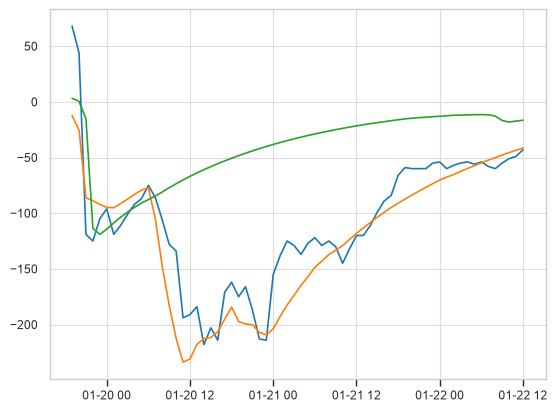

In [75]:
sc_0_mask = np.where((sc_0_hour.time >= gs_start) & (sc_0_hour.time <= gs_end))[0]
sc_1_mask = np.where((sc_1_hour.time >= gs_start) & (sc_1_hour.time <= gs_end))[0]

df_dst_cut = df_dst[(df_dst.time >= gs_start) & (df_dst.time <= gs_end)]


sc_0_cut = sc_0_hour.iloc[sc_0_mask]
sc_1_cut = sc_1_hour.iloc[sc_1_mask]
Dst_hour_cut = Dst_hour[sc_0_mask]
Dst_hour_solo_cut = Dst_hour_solo[sc_1_mask]



plt.plot(df_dst_cut.time, df_dst_cut.dst)
plt.plot(sc_0_cut.time, Dst_hour_cut)
plt.plot(sc_1_cut.time, Dst_hour_solo_cut)

def rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())

rmse_l1_obs = rmse(Dst_hour_cut, df_dst_cut.dst)
rmse_solo_obs = rmse(Dst_hour_solo_cut, df_dst_cut.dst)
rmse_solo_l1 = rmse(Dst_hour_cut, Dst_hour_solo_cut)

print('RMSE L1, Obs: ', np.round(rmse_l1_obs,1), 'nT')
print('RMSE SolO, Obs: ', np.round(rmse_solo_obs,1), 'nT')
print('RMSE SolO, L1: ', np.round(rmse_solo_l1,1), 'nT')

In [ ]:
gs_start_time = apr_gs_start

# This part is for ELEvo-Movie only

In [46]:
def cart2sphere(x,y,z):
    r = np.sqrt(x**2+ y**2 + z**2)           
    theta = np.arctan2(z,np.sqrt(x**2+ y**2))
    phi = np.arctan2(y,x)                    
    return (r, theta, phi)

def plot_stereo_hi_fov(pos, time_num, timeind,ax,sc):    
    
    #plots the STA FOV HI1 HI2
    
    #STB never flipped the camera:    
    if sc=='B': 
        ang1d=-4
        ang2d=-24
        ang3d=-18
        ang4d=-88
        lcolor='blue'
    
    if sc=='A': 
        ang1d=4
        ang2d=24
        ang3d=18
        ang4d=88
        lcolor='red'

        #STA flipped during conjunction
        if mdates.date2num(datetime(2015,11,1))<time_num<mdates.date2num(datetime(2023,8,12)):  
            ang1d=-4
            ang2d=-24
            ang3d=-18
            ang4d=-88



    #calculate endpoints
    
    #sta position
    x0=pos.x[timeind]
    y0=pos.y[timeind]
    z0=0
    
    #sta position 180° rotated    
    x1=-pos.x[timeind]
    y1=-pos.y[timeind]
    z1=0
    
    #rotate by 4 deg for HI1 FOV
    ang=np.deg2rad(ang1d)
    rot=np.array([[np.cos(ang), -np.sin(ang)], [np.sin(ang), np.cos(ang)]])    
    [x2,y2]=np.dot(rot,[x1,y1])
    z2=0    
    #add to sta position
    x2f=x0+x2
    y2f=y0+y2    
    z2f=0
    
    #rotate 2
    ang2=np.deg2rad(ang2d)
    rot2=np.array([[np.cos(ang2), -np.sin(ang2)], [np.sin(ang2), np.cos(ang2)]])    
    [x3,y3]=np.dot(rot2,[x1,y1])
    z3=0    
    #add to sta position
    x3f=x0+x3
    y3f=y0+y3    
    z3f=0
    
    #rotate 3
    ang3=np.deg2rad(ang3d)
    rot3=np.array([[np.cos(ang3), -np.sin(ang3)], [np.sin(ang3), np.cos(ang3)]])    
    [x4,y4]=np.dot(rot3,[x1,y1])
    z4=0    
    #add to sta position
    x4f=x0+x4
    y4f=y0+y4    
    z4f=0    

    #rotate 4
    ang4=np.deg2rad(ang4d)
    rot4=np.array([[np.cos(ang4), -np.sin(ang4)], [np.sin(ang4), np.cos(ang4)]])    
    [x5,y5]=np.dot(rot4,[x1,y1])
    z5=0    
    #add to sta position
    x5f=x0+x5
    y5f=y0+y5    
    z5f=0    

    
    #convert to polar coordinates and plot
    [r0,t0,lon0]=cart2sphere(x0,y0,z0)    
    #[r1,t1,lon1]=hd.cart2sphere(x1,y1,z1)    
    [r2,t2,lon2]=cart2sphere(x2f,y2f,z2f)    
    [r3,t3,lon3]=cart2sphere(x3f,y3f,z3f)    
    [r4,t4,lon4]=cart2sphere(x4f,y4f,z4f)    
    [r5,t5,lon5]=cart2sphere(x5f,y5f,z5f)    
    
    #ax.plot([lon0,lon1],[r0,r1],'--r',alpha=0.5)
    ax.plot([lon0,lon2],[r0,r2],linestyle='-',color=lcolor,alpha=0.3, lw=0.8)
    ax.plot([lon0,lon3],[r0,r3],linestyle='-',color=lcolor,alpha=0.3, lw=0.8)
    ax.plot([lon0,lon4],[r0,r4],linestyle='--',color=lcolor,alpha=0.3, lw=0.8)
    ax.plot([lon0,lon5],[r0,r5],linestyle='--',color=lcolor,alpha=0.3, lw=0.8)

In [47]:
def make_frame(k):
    '''
    loop each frame in multiprocessing
    '''
    
    fig=plt.figure(1, figsize=(19.2,10.8), dpi=100) #full hd
    #fig=plt.figure(1, figsize=(19.2*2,10.8*2), dpi=100) #4k
    ax = plt.subplot2grid((4,2), (0, 0), rowspan=4, projection='polar')
    backcolor='black'
    psp_color='black'
    bepi_color='blue'
    solo_color='coral'
    cme1=c3
    cme2='coral'
    

    frame_time_str=str(mdates.num2date(frame_time_num+k*res_in_days))
    
    #these have their own times
    
    dct=frame_time_num+k*res_in_days-psp.time
    psp_timeind=np.argmin(abs(dct))

    dct=frame_time_num+k*res_in_days-bepi.time 
    bepi_timeind=np.argmin(abs(dct))

    dct=frame_time_num+k*res_in_days-solo.time
    solo_timeind=np.argmin(abs(dct))
    
    dct=frame_time_num+k*res_in_days-sta.time
    sta_timeind=np.argmin(abs(dct))

    #all same times
    dct=frame_time_num+k*res_in_days-earth.time
    earth_timeind=np.argmin(abs(dct))

    #plot all positions including text R lon lat for some 

    #white background

    ax.scatter(venus.lon[earth_timeind], venus.r[earth_timeind]*np.cos(venus.lat[earth_timeind]), s=symsize_planet, c='tab:purple', alpha=1,lw=0,zorder=3)
    ax.scatter(mercury.lon[earth_timeind], mercury.r[earth_timeind]*np.cos(mercury.lat[earth_timeind]), s=symsize_planet, c='dimgrey', alpha=1,lw=0,zorder=3)
    ax.scatter(earth.lon[earth_timeind], earth.r[earth_timeind]*np.cos(earth.lat[earth_timeind]), s=symsize_planet, c='mediumseagreen', alpha=1,lw=0,zorder=3)
    ax.scatter(sta.lon[sta_timeind], sta.r[sta_timeind]*np.cos(sta.lat[sta_timeind]), s=symsize_spacecraft, c='red', marker='s', alpha=1,lw=0,zorder=3)
    ax.scatter(mars.lon[earth_timeind], mars.r[earth_timeind]*np.cos(mars.lat[earth_timeind]), s=symsize_planet, c='orangered', alpha=0.7,lw=0,zorder=3)


    #plot stereoa fov hi1/2    
    plot_stereo_hi_fov(sta,frame_time_num, sta_timeind, ax,'A')



    #positions text
    f10=plt.figtext(0.01,0.93,'              R     lon     lat', fontsize=fsize+2, ha='left',color=backcolor)

    if frame=='HEEQ': earth_text='Earth: '+str(f'{earth.r[earth_timeind]:6.2f}')+str(f'{0.0:8.1f}')+str(f'{np.rad2deg(earth.lat[earth_timeind]):8.1f}')
    else: earth_text='Earth: '+str(f'{earth.r[earth_timeind]:6.2f}')+str(f'{np.rad2deg(earth.lon[earth_timeind]):8.1f}')+str(f'{np.rad2deg(earth.lat[earth_timeind]):8.1f}')

    mars_text='Mars:  '+str(f'{mars.r[earth_timeind]:6.2f}')+str(f'{np.rad2deg(mars.lon[earth_timeind]):8.1f}')+str(f'{np.rad2deg(mars.lat[earth_timeind]):8.1f}')
    sta_text='STA:   '+str(f'{sta.r[sta_timeind]:6.2f}')+str(f'{np.rad2deg(sta.lon[sta_timeind]):8.1f}')+str(f'{np.rad2deg(sta.lat[sta_timeind]):8.1f}')

    #position and text 
    if psp_timeind > 0:
        #plot trajectorie
        ax.scatter(psp.lon[psp_timeind], psp.r[psp_timeind]*np.cos(psp.lat[psp_timeind]), s=symsize_spacecraft, c=psp_color, marker='s', linestyle='--', alpha=1,lw=0,zorder=3)
        #plot positiona as text
        psp_text='PSP:   '+str(f'{psp.r[psp_timeind]:6.2f}')+str(f'{np.rad2deg(psp.lon[psp_timeind]):8.1f}')+str(f'{np.rad2deg(psp.lat[psp_timeind]):8.1f}')
        f5=plt.figtext(0.01,0.78,psp_text, fontsize=fsize, ha='left',color=psp_color)
        if plot_orbit: 
            fadestart=psp_timeind-fadeind
            if  fadestart < 0: fadestart=0
            ax.plot(psp.lon[fadestart:psp_timeind+fadeind], psp.r[fadestart:psp_timeind+fadeind]*np.cos(psp.lat[fadestart:psp_timeind+fadeind]), c=psp_color, linestyle='--', alpha=0.6,lw=1,zorder=3)
    
    if bepi_timeind > 0:
        ax.scatter(bepi.lon[bepi_timeind], bepi.r[bepi_timeind]*np.cos(bepi.lat[bepi_timeind]), s=symsize_spacecraft, c=bepi_color, marker='s', alpha=1,lw=0,zorder=3)
        bepi_text='Bepi:   '+str(f'{bepi.r[bepi_timeind]:6.2f}')+str(f'{np.rad2deg(bepi.lon[bepi_timeind]):8.1f}')+str(f'{np.rad2deg(bepi.lat[bepi_timeind]):8.1f}')
        f6=plt.figtext(0.01,0.74,bepi_text, fontsize=fsize, ha='left',color=bepi_color)
        if plot_orbit: 
            fadestart=bepi_timeind-fadeind
            if  fadestart < 0: fadestart=0            
            ax.plot(bepi.lon[fadestart:bepi_timeind+fadeind], bepi.r[fadestart:bepi_timeind+fadeind]*np.cos(bepi.lat[fadestart:bepi_timeind+fadeind]), c=bepi_color, linestyle='--', alpha=0.6,lw=1,zorder=3)
    
    if solo_timeind > 0:
        ax.scatter(solo.lon[solo_timeind], solo.r[solo_timeind]*np.cos(solo.lat[solo_timeind]), s=symsize_spacecraft, c=solo_color, marker='s', alpha=1,lw=0,zorder=3)
        solo_text='SolO:  '+str(f'{solo.r[solo_timeind]:6.2f}')+str(f'{np.rad2deg(solo.lon[solo_timeind]):8.1f}')+str(f'{np.rad2deg(solo.lat[solo_timeind]):8.1f}')
        f7=plt.figtext(0.01,0.7,solo_text, fontsize=fsize, ha='left',color=solo_color)
        if plot_orbit: 
            fadestart=solo_timeind-fadeind
            if  fadestart < 0: fadestart=0            
            ax.plot(solo.lon[fadestart:solo_timeind+fadeind], solo.r[fadestart:solo_timeind+fadeind]*np.cos(solo.lat[fadestart:solo_timeind+fadeind]), c=solo_color, linestyle='--', alpha=0.6,lw=1,zorder=3)

    f10=plt.figtext(0.01,0.9,earth_text, fontsize=fsize, ha='left',color='mediumseagreen')
    f9=plt.figtext(0.01,0.86,mars_text, fontsize=fsize, ha='left',color='orangered')
    f8=plt.figtext(0.01,0.82,sta_text, fontsize=fsize, ha='left',color='red')
    

    ######################## 1 plot all active CME circles

    cmeind1=np.where(hc_time_num1 == frame_time_num+k*res_in_days)
    
    plot_hi_geo=True    
    
    if plot_hi_geo:

        for p in range(0,np.size(cmeind1)):
            
            t = ((np.arange(201)-10)*np.pi/180)-(hc_lon1[cmeind1[0][p]]*np.pi/180)
            t1 = ((np.arange(201)-10)*np.pi/180)
            
            longcirc1 = []
            rcirc1 = []
            for i in range(3):

                xc1 = c1_ell[i][cmeind1[0][p]]*np.cos(hc_lon1[cmeind1[0][p]]*np.pi/180)+((a1_ell[i][cmeind1[0][p]]*b1_ell[i][cmeind1[0][p]])/np.sqrt((b1_ell[i][cmeind1[0][p]]*np.cos(t1))**2+(a1_ell[i][cmeind1[0][p]]*np.sin(t1))**2))*np.sin(t)
                yc1 = c1_ell[i][cmeind1[0][p]]*np.sin(hc_lon1[cmeind1[0][p]]*np.pi/180)+((a1_ell[i][cmeind1[0][p]]*b1_ell[i][cmeind1[0][p]])/np.sqrt((b1_ell[i][cmeind1[0][p]]*np.cos(t1))**2+(a1_ell[i][cmeind1[0][p]]*np.sin(t1))**2))*np.cos(t)

                longcirc1.append(np.arctan2(yc1, xc1))
                rcirc1.append(np.sqrt(xc1**2+yc1**2))
            
            if p == 0:
                ax.plot(longcirc1[0],rcirc1[0], color=cme1, ls='-', alpha=1-abs(hc_lat1[cmeind1[0][p]]/100), lw=1.5) 
                ax.fill_between(longcirc1[2], rcirc1[2], rcirc1[1], color=cme1, alpha=.05)
            if p == 1:
                ax.plot(longcirc1[0],rcirc1[0], color=cme2, ls='-', alpha=1-abs(hc_lat1[cmeind1[0][p]]/100), lw=1.5) 
                ax.fill_between(longcirc1[2], rcirc1[2], rcirc1[1], color=cme2, alpha=.05)

    #set axes and grid
    ax.set_theta_zero_location('E')
    #plt.thetagrids(range(0,360,45),(u'0\u00b0 '+frame+' longitude',u'45\u00b0',u'90\u00b0',u'135\u00b0',u'+/- 180\u00b0',u'- 135\u00b0',u'- 90\u00b0',u'- 45\u00b0'), ha='right', fmt='%d',fontsize=fsize-1,color=backcolor, alpha=0.9)
    plt.thetagrids(range(0,360,45),(u'0\u00b0',u'45\u00b0',u'90\u00b0',u'135\u00b0',u'+/- 180\u00b0',u'- 135\u00b0',u'- 90\u00b0',u'- 45\u00b0'), ha='center', fmt='%d',fontsize=fsize-1,color=backcolor, alpha=0.9,zorder=4)


    #plt.rgrids((0.10,0.39,0.72,1.00,1.52),('0.10','0.39','0.72','1.0','1.52 AU'),angle=125, fontsize=fsize,alpha=0.9, color=backcolor)
    plt.rgrids((0.1,0.3,0.5,0.7,1.0),('0.10','0.3','0.5','0.7','1.0 AU'),angle=125, fontsize=fsize-3,alpha=0.5, color=backcolor)

    #ax.set_ylim(0, 1.75) #with Mars
    ax.set_ylim(0, 1.2)

    #Sun
    ax.scatter(0,0,s=100,c='yellow',alpha=1, edgecolors='black', linewidth=0.3)


    

    #------------------------------------------------ IN SITU DATA ------------------------------------------------------


    time_now=frame_time_num+k*res_in_days
  
    #cut data for plot window so faster

    if n_time_num[-1] > time_now+days_window:
        nindex1=np.where(n_time_num > time_now-days_window)[0][0]
        nindex2=np.where(n_time_num > time_now+days_window)[0][0]
        #use last index   oindex2=np.size(o1)-1
        n=n1[nindex1:nindex2]
        if np.isnan(n.bt).all():
            n.bt=np.nan
    elif np.logical_and((n_time_num[-1] < time_now+days_window),(n_time_num[-1] > time_now-days_window)):
        nindex1=np.where(n_time_num > time_now-days_window)[0][0]
        nindex2=np.size(n1)-1
        n=n1[nindex1:nindex2]
    else: n=[] 
    
    
    if s_time_num[-1] > time_now+days_window:
        sindex1=np.where(s_time_num > time_now-days_window)[0][0]
        sindex2=np.where(s_time_num > time_now+days_window)[0][0]
        s=s1[sindex1:sindex2]
        if np.isnan(s.bt).all():
            s.bt=np.nan
    elif np.logical_and((s_time_num[-1] < time_now+days_window),(s_time_num[-1] > time_now-days_window)):
        sindex1=np.where(s_time_num > time_now-days_window)[0][0]
        sindex2=np.size(s1)-1
        s=s1[sindex1:sindex2]
    else: s=[] 
    
    
    if o_time_num[-1] > time_now+days_window:
        oindex1=np.where(o_time_num > time_now-days_window)[0][0]
        oindex2=np.where(o_time_num > time_now+days_window)[0][0]
        o=o1[oindex1:oindex2]
        if np.isnan(o.bt).all():
            o.bt=np.nan
    elif np.logical_and((o_time_num[-1] < time_now+days_window),(o_time_num[-1] > time_now-days_window)):
        oindex1=np.where(o_time_num > time_now-days_window)[0][0]
        oindex2=np.size(s1)-1
        o=o1[oindex1:oindex2]
    else: o=[] 

    #---------------- NOAA mag

    ax4 = plt.subplot2grid((4,2), (0, 1))
    ax4.plot([time_now,time_now], [-1000,1000],'-k', lw=0.7, alpha=0.8)
    ax4.plot([hc_arr_time1[0],hc_arr_time1[0]], [-1000,1000],'-k', lw=1, alpha=0.8, color=cme1)
    ax4.plot([hc_arr_time1[1],hc_arr_time1[1]], [-1000,1000],'-k', lw=1, alpha=0.8, color=cme2)
    #ax4.plot([hc_err_arr_time_min1,hc_err_arr_time_min1], [-1000,1000],'-k', lw=0.5, alpha=0.4, color='tab:blue')
    #ax4.plot([hc_err_arr_time_max1,hc_err_arr_time_max1], [-1000,1000],'-k', lw=0.5, alpha=0.4, color='tab:blue')

    ax4.set_xticklabels([])
    ax4.set_xlim(time_now-days_window,time_now+days_window)
    ax4.set_ylabel('B [nT] GSM',fontsize=fsize-1)
    plt.yticks(fontsize=fsize-1)

    #when there is data, plot:
    
    if np.size(n)>0:
    
        plt.plot(n.time,n.bx,'-r',label='BR',linewidth=0.5)
        plt.plot(n.time,n.by,'-g',label='BT',linewidth=0.5)
        plt.plot(n.time,n.bz,'-b',label='BN',linewidth=0.5)
        plt.plot(n.time,n.bt,'-k',label='Btotal',lw=0.5)
        
        #for i in range(len(hc_arr_time1)):
         #   if np.isnan(hc_arr_hit1[i]) == False:       
               # ax4.axvspan(hc_err_arr_time_min1[i], hc_err_arr_time_max1[i], alpha=0.04, color='tab:blue')
               # ax4.annotate(hc_arr_id1[i][0:16], (hc_arr_time1[i], np.nanmax(n.bt)+5), fontsize=10, rotation=90)
                
        if np.isfinite(np.nanmin(-n.bt)):         
            ax4.set_ylim(np.nanmin(-n.bt)-5, np.nanmax(n.bt)+5)
       
                




    #----------------  STEREO-A mag
    
    ax6 = plt.subplot2grid((4,2), (1, 1))
    ax6.plot([time_now,time_now], [-100,100],'-k', lw=0.5, alpha=0.8)    
    #ax6.plot([hc_arr_time1[0],hc_arr_time1[0]], [-1000,1000],'-k', lw=1, alpha=0.8, color='tab:blue')
    #ax6.plot([hc_arr_time1[1],hc_arr_time1[1]], [-1000,1000],'-k', lw=1, alpha=0.8, color='tab:orange')
    #ax6.plot([hc_err_arr_time_min1,hc_err_arr_time_min1], [-1000,1000],'-k', lw=0.5, alpha=0.4, color='tab:blue')
    #ax6.plot([hc_err_arr_time_max1,hc_err_arr_time_max1], [-1000,1000],'-k', lw=0.5, alpha=0.4, color='tab:blue')
    #for i in range(len(hc_arr_time1)):
     #   ax6.axvspan(hc_err_arr_time_min1[i], hc_err_arr_time_max1[i], alpha=0.04, color='tab:blue')
        
    ax6.set_xlim(time_now-days_window,time_now+days_window)
    ax6.set_xticklabels([])
    ax6.set_ylabel('B [nT] GSM',fontsize=fsize-1)
    plt.yticks(fontsize=fsize-1) 
    plt.tick_params( axis='x', labelbottom='off')
    
    if np.size(s)>0:
        
        plt.plot(s.time,s.bx,'-r',label='BR',linewidth=0.5)
        plt.plot(s.time,s.by,'-g',label='BT',linewidth=0.5)
        plt.plot(s.time,s.bz,'-b',label='BN',linewidth=0.5)
        plt.plot(s.time,s.bt,'-k',label='Btotal',linewidth=0.5)
    
        if np.isfinite(np.nanmin(-s.bt)):         
            ax6.set_ylim(np.nanmin(-s.bt)-5, np.nanmax(s.bt)+5)
            
            
            
    # ----------------- SolO mag        
    ax7 = plt.subplot2grid((4,2), (2, 1))
    ax7.plot([time_now,time_now], [-1000,1000],'-k', lw=0.5, alpha=0.8)
    ax7.plot([hc_arr_time1_solo[0],hc_arr_time1_solo[0]], [-1000,1000],'-k', lw=1, alpha=0.8, color=cme1)
    ax7.plot([hc_arr_time1_solo[1],hc_arr_time1_solo[1]], [-1000,1000],'-k', lw=1, alpha=0.8, color=cme2)
    #ax7.plot([hc_err_arr_time_min1_solo,hc_err_arr_time_min1_solo], [-1000,1000],'-k', lw=0.5, alpha=0.4, color='tab:orange')
    #ax7.plot([hc_err_arr_time_max1_solo,hc_err_arr_time_max1_solo], [-1000,1000],'-k', lw=0.5, alpha=0.4, color='tab:orange')
    #for i in range(len(hc_arr_time1_solo)):
     #   ax7.axvspan(hc_err_arr_time_min1_solo[i], hc_err_arr_time_max1_solo[i], alpha=0.04, color='tab:orange')
        
    ax7.set_xlim(time_now-days_window,time_now+days_window)
    ax7.set_xticklabels([])
    ax7.set_ylabel('B [nT] GSM',fontsize=fsize-1)
    plt.yticks(fontsize=fsize-1) 
    plt.tick_params( axis='x', labelbottom='off')
    
    if np.size(o)>0:
        
        plt.plot(o.time,o.bx,'-r',label='BR',linewidth=0.5)
        plt.plot(o.time,o.by,'-g',label='BT',linewidth=0.5)
        plt.plot(o.time,o.bz,'-b',label='BN',linewidth=0.5)
        plt.plot(o.time,o.bt,'-k',label='Btotal',linewidth=0.5)
    
        if np.isfinite(np.nanmin(-o.bt)):         
            ax7.set_ylim(np.nanmin(-o.bt)-5, np.nanmax(o.bt)+10)
        
    
    #----------------  STEREO, NOAA speed    
    
    ax5 = plt.subplot2grid((4,2), (3, 1))
    ax5.set_xlim(time_now-days_window,time_now+days_window)
    ax5.plot([time_now,time_now], [-100,1000],'-k', lw=0.5, alpha=0.8)
    ax5.plot([hc_arr_time1[0],hc_arr_time1[0]], [-1000,1000],'-k', lw=1, alpha=0.8, color=cme1)
    ax5.plot([hc_arr_time1[1],hc_arr_time1[1]], [-1000,1000],'-k', lw=1, alpha=0.8, color=cme2)
    #ax5.plot([hc_err_arr_time_min1,hc_err_arr_time_min1], [-1000,1000],'-k', lw=0.5, alpha=0.4, color='tab:blue')
    #ax5.plot([hc_err_arr_time_max1,hc_err_arr_time_max1], [-1000,1000],'-k', lw=0.5, alpha=0.4, color='tab:blue')
    #for i in range(len(hc_arr_time1)):
     #   ax5.axvspan(hc_err_arr_time_min1[i], hc_err_arr_time_max1[i], alpha=0.04, color='tab:blue')
    plt.ylabel('V [km/s]',fontsize=fsize-1)
    plt.ylim((240, 900))
    plt.yticks(fontsize=fsize-1)
    ax5.xaxis.set_major_formatter( matplotlib.dates.DateFormatter('%b-%d') )
    #ax5.set_xticklabels([])
    
    if np.size(s)>0:
        plt.plot(s.time,s.vt,'-r',label='STEREO-A',linewidth=0.7)
        
    if np.size(n)>0:
        plt.plot(n.time,n.vt,'-g',label='V',linewidth=0.7)
        plt.ylim(250., np.nanmax(n.vt)+20)
        
    else:
        plt.ylim(250., 800)
        
    #if np.isfinite(np.nanmin(n.bt)):    
    #ax5.set_ylim(np.nanmin(-n.bt)-50, np.nanmax(n.bt)+50)


    plt.figtext(0.95,0.77,'NOAA', color='mediumseagreen', ha='center',fontsize=fsize+3)
    plt.figtext(0.95,0.58,'STEREO-A', color='red', ha='center',fontsize=fsize+3)
    plt.figtext(0.95,0.40,'SolarOrbiter', color='coral', ha='center',fontsize=fsize+3)
    plt.figtext(0.95,0.23,'NOAA', color='mediumseagreen', ha='center',fontsize=fsize+3)
    plt.figtext(0.95,0.18,'STEREO-A', color='red', ha='center',fontsize=fsize+3)
    plt.figtext(0.92,0.91,r'B$_{\mathrm{x}}$', color='red', ha='center',fontsize=fsize)
    plt.figtext(0.94,0.91,r'B$_{\mathrm{y}}$', color='green', ha='center',fontsize=fsize)
    plt.figtext(0.96,0.91,r'B$_{\mathrm{z}}$', color='blue', ha='center',fontsize=fsize)
    plt.figtext(0.98,0.91,r'B$_{\mathrm{tot}}$', color='black', ha='center',fontsize=fsize)
    
    ############################

    #plot text for date extra so it does not move 
    f0=plt.figtext(0.207,0.93,str(mdates.num2date(frame_time_num+k*res_in_days).strftime('%A'))[0:3],  ha='left',color=backcolor,fontsize=fsize+6)
    #year
    f1=plt.figtext(0.24,0.93,frame_time_str[0:4],  ha='left',color=backcolor,fontsize=fsize+6)
    #month
    f2=plt.figtext(0.24+0.04,0.93,frame_time_str[5:7], ha='left',color=backcolor,fontsize=fsize+6)
    #day
    f3=plt.figtext(0.245+0.06,0.93,frame_time_str[8:10], ha='left',color=backcolor,fontsize=fsize+6)
    #hours
    f4=plt.figtext(0.24+0.09,0.93,frame_time_str[11:13], ha='left',color=backcolor,fontsize=fsize+6)
    
    f5=plt.figtext(0.24+0.13,0.93,'UTC', ha='center',color=backcolor,fontsize=fsize+6)
    
    #plt.figtext(0.02, 0.08, 'created: '+ str(today.strftime('%A'))[0:3] + ' ' + date_today_minutes + ' UTC', fontsize=fsize-3, ha='left', color=backcolor)
    
    plt.figtext(0.02, 0.1,'DONKI (CCMC) - kinematics: ELEvo', fontsize=fsize-1, ha='left',color='tab:blue')
    
    plt.figtext(0.02, 0.033,'Spacecraft trajectories '+frame+' 2D projection', fontsize=fsize-1, ha='left',color=backcolor)
    
    plt.figtext(0.34,0.033,r'---- trajectory from $-\,30$ days to $+\,30$ days', color='black', ha='center',fontsize=fsize-1)

    #signature
    
    #BC MPO-MAG (IGEP/IWF/ISAS/IC)
    #auch für Solar Orbiter (MAG, IC), Parker (FIELDS, UCB), STA (IMPACT/PLASTIC, UNH, UCLA), Wind (MFI, SWE, NASA??) STA-HI (RAL)

    plt.figtext(0.87,0.033,'Data sources: NOAA L1 RTSW, STEREO-A (IMPACT/PLASTIC, UNH, UCLA)', fontsize=fsize-2, ha='right',color=backcolor) 


    
    #signature
    plt.figtext(0.02,0.01/2,r'Austrian Space Weather Office, GeoSphere Austria', fontsize=fsize-4, ha='left',color=backcolor) 
    plt.figtext(0.99,0.01/2,'helioforecast.space', fontsize=fsize-4, ha='right',color=backcolor) 
    
    #logo = plt.imread('/perm/aswo/eweiler/ELEvo/logo/GSA_Basislogo_Positiv_RGB_XXS.png')
    #newax = fig.add_axes([0.91,0.91,0.08,0.08], anchor='NE', zorder=1)
    #newax.imshow(logo)
    #newax.axis('off') 
        
    categories = np.array([0, 2, 1, 1, 1, 2, 0, 0])

    colormap = np.array(['r', 'g', 'b'])
    
    
    steps=60
    #parker spiral
    if plot_parker:
        for q in np.arange(0,steps):
            omega=2*np.pi/(sun_rot*60*60*24) #solar rotation in seconds
            v=400/AUkm #km/s
            r0=695000/AUkm
            r=v/omega*theta+r0*7
            ax.plot(-theta+np.deg2rad(0+(360/24.47)*res_in_days*k+360/12*q), r, alpha=0.1, lw=0.5,color='grey',zorder=2)



    #save figure
    framestr = '%05i' % (k)
    filename=outputdirectory+'/pos_anim_'+framestr+'.jpg'  
    #if k==0: print(filename)
    plt.savefig(filename,dpi=200,facecolor=fig.get_facecolor(), edgecolor='none')
    #plt.clf()
    #if close==True: plt.close('all')


    plt.close('all')


In [48]:
def make_frame_march(k):
    '''
    loop each frame in multiprocessing
    '''
    

    fig=plt.figure(1, figsize=(19.2,10.8), dpi=100) #full hd
    #fig=plt.figure(1, figsize=(19.2*2,10.8*2), dpi=100) #4k
    ax = plt.subplot2grid((4,2), (0, 0), rowspan=4, projection='polar')
    backcolor='black'
    psp_color='black'
    bepi_color='blue'
    solo_color='coral'


    frame_time_str=str(mdates.num2date(frame_time_num+k*res_in_days))
    
    #these have their own times
    
    dct=frame_time_num+k*res_in_days-psp.time
    psp_timeind=np.argmin(abs(dct))

    dct=frame_time_num+k*res_in_days-bepi.time 
    bepi_timeind=np.argmin(abs(dct))

    dct=frame_time_num+k*res_in_days-solo.time
    solo_timeind=np.argmin(abs(dct))
    
    dct=frame_time_num+k*res_in_days-sta.time
    sta_timeind=np.argmin(abs(dct))

    #all same times
    dct=frame_time_num+k*res_in_days-earth.time
    earth_timeind=np.argmin(abs(dct))

    #plot all positions including text R lon lat for some 

    #white background

    ax.scatter(venus.lon[earth_timeind], venus.r[earth_timeind]*np.cos(venus.lat[earth_timeind]), s=symsize_planet, c='tab:purple', alpha=1,lw=0,zorder=3)
    ax.scatter(mercury.lon[earth_timeind], mercury.r[earth_timeind]*np.cos(mercury.lat[earth_timeind]), s=symsize_planet, c='dimgrey', alpha=1,lw=0,zorder=3)
    ax.scatter(earth.lon[earth_timeind], earth.r[earth_timeind]*np.cos(earth.lat[earth_timeind]), s=symsize_planet, c='mediumseagreen', alpha=1,lw=0,zorder=3)
    ax.scatter(sta.lon[sta_timeind], sta.r[sta_timeind]*np.cos(sta.lat[sta_timeind]), s=symsize_spacecraft, c='red', marker='s', alpha=1,lw=0,zorder=3)
    ax.scatter(mars.lon[earth_timeind], mars.r[earth_timeind]*np.cos(mars.lat[earth_timeind]), s=symsize_planet, c='orangered', alpha=0.7,lw=0,zorder=3)


    #plot stereoa fov hi1/2    
    plot_stereo_hi_fov(sta,frame_time_num, sta_timeind, ax,'A')



    #positions text
    f10=plt.figtext(0.01,0.93,'              R     lon     lat', fontsize=fsize+2, ha='left',color=backcolor)

    if frame=='HEEQ': earth_text='Earth: '+str(f'{earth.r[earth_timeind]:6.2f}')+str(f'{0.0:8.1f}')+str(f'{np.rad2deg(earth.lat[earth_timeind]):8.1f}')
    else: earth_text='Earth: '+str(f'{earth.r[earth_timeind]:6.2f}')+str(f'{np.rad2deg(earth.lon[earth_timeind]):8.1f}')+str(f'{np.rad2deg(earth.lat[earth_timeind]):8.1f}')

    mars_text='Mars:  '+str(f'{mars.r[earth_timeind]:6.2f}')+str(f'{np.rad2deg(mars.lon[earth_timeind]):8.1f}')+str(f'{np.rad2deg(mars.lat[earth_timeind]):8.1f}')
    sta_text='STA:   '+str(f'{sta.r[sta_timeind]:6.2f}')+str(f'{np.rad2deg(sta.lon[sta_timeind]):8.1f}')+str(f'{np.rad2deg(sta.lat[sta_timeind]):8.1f}')

    #position and text 
    if psp_timeind > 0:
        #plot trajectorie
        ax.scatter(psp.lon[psp_timeind], psp.r[psp_timeind]*np.cos(psp.lat[psp_timeind]), s=symsize_spacecraft, c=psp_color, marker='s', linestyle='--', alpha=1,lw=0,zorder=3)
        #plot positiona as text
        psp_text='PSP:   '+str(f'{psp.r[psp_timeind]:6.2f}')+str(f'{np.rad2deg(psp.lon[psp_timeind]):8.1f}')+str(f'{np.rad2deg(psp.lat[psp_timeind]):8.1f}')
        f5=plt.figtext(0.01,0.78,psp_text, fontsize=fsize, ha='left',color=psp_color)
        if plot_orbit: 
            fadestart=psp_timeind-fadeind
            if  fadestart < 0: fadestart=0
            ax.plot(psp.lon[fadestart:psp_timeind+fadeind], psp.r[fadestart:psp_timeind+fadeind]*np.cos(psp.lat[fadestart:psp_timeind+fadeind]), c=psp_color, linestyle='--', alpha=0.6,lw=1,zorder=3)
    
    if bepi_timeind > 0:
        ax.scatter(bepi.lon[bepi_timeind], bepi.r[bepi_timeind]*np.cos(bepi.lat[bepi_timeind]), s=symsize_spacecraft, c=bepi_color, marker='s', alpha=1,lw=0,zorder=3)
        bepi_text='Bepi:   '+str(f'{bepi.r[bepi_timeind]:6.2f}')+str(f'{np.rad2deg(bepi.lon[bepi_timeind]):8.1f}')+str(f'{np.rad2deg(bepi.lat[bepi_timeind]):8.1f}')
        f6=plt.figtext(0.01,0.74,bepi_text, fontsize=fsize, ha='left',color=bepi_color)
        if plot_orbit: 
            fadestart=bepi_timeind-fadeind
            if  fadestart < 0: fadestart=0            
            ax.plot(bepi.lon[fadestart:bepi_timeind+fadeind], bepi.r[fadestart:bepi_timeind+fadeind]*np.cos(bepi.lat[fadestart:bepi_timeind+fadeind]), c=bepi_color, linestyle='--', alpha=0.6,lw=1,zorder=3)
    
    if solo_timeind > 0:
        ax.scatter(solo.lon[solo_timeind], solo.r[solo_timeind]*np.cos(solo.lat[solo_timeind]), s=symsize_spacecraft, c=solo_color, marker='s', alpha=1,lw=0,zorder=3)
        solo_text='SolO:  '+str(f'{solo.r[solo_timeind]:6.2f}')+str(f'{np.rad2deg(solo.lon[solo_timeind]):8.1f}')+str(f'{np.rad2deg(solo.lat[solo_timeind]):8.1f}')
        f7=plt.figtext(0.01,0.7,solo_text, fontsize=fsize, ha='left',color=solo_color)
        if plot_orbit: 
            fadestart=solo_timeind-fadeind
            if  fadestart < 0: fadestart=0            
            ax.plot(solo.lon[fadestart:solo_timeind+fadeind], solo.r[fadestart:solo_timeind+fadeind]*np.cos(solo.lat[fadestart:solo_timeind+fadeind]), c=solo_color, linestyle='--', alpha=0.6,lw=1,zorder=3)

    f10=plt.figtext(0.01,0.9,earth_text, fontsize=fsize, ha='left',color='mediumseagreen')
    f9=plt.figtext(0.01,0.86,mars_text, fontsize=fsize, ha='left',color='orangered')
    f8=plt.figtext(0.01,0.82,sta_text, fontsize=fsize, ha='left',color='red')
    

    ######################## 1 plot all active CME circles

    #cmeind1=np.where(hc_time_num1 == frame_time_num+k*res_in_days)
    cmeind1=np.where(hc_time1 == frame_time+timedelta(days=k*res_in_days))
    #print(cmeind1)
    #print(mdates.num2date(frame_time_num+k*res_in_days))
    
    plot_hi_geo=True    
    
    if plot_hi_geo:

        for p in range(0,np.size(cmeind1)):
            
            t = ((np.arange(201)-10)*np.pi/180)-(hc_lon1[cmeind1[0][p]]*np.pi/180)
            t1 = ((np.arange(201)-10)*np.pi/180)
            
            longcirc1 = []
            rcirc1 = []
            for i in range(3):

                xc1 = c1_ell[i][cmeind1[0][p]]*np.cos(hc_lon1[cmeind1[0][p]]*np.pi/180)+((a1_ell[i][cmeind1[0][p]]*b1_ell[i][cmeind1[0][p]])/np.sqrt((b1_ell[i][cmeind1[0][p]]*np.cos(t1))**2+(a1_ell[i][cmeind1[0][p]]*np.sin(t1))**2))*np.sin(t)
                yc1 = c1_ell[i][cmeind1[0][p]]*np.sin(hc_lon1[cmeind1[0][p]]*np.pi/180)+((a1_ell[i][cmeind1[0][p]]*b1_ell[i][cmeind1[0][p]])/np.sqrt((b1_ell[i][cmeind1[0][p]]*np.cos(t1))**2+(a1_ell[i][cmeind1[0][p]]*np.sin(t1))**2))*np.cos(t)

                longcirc1.append(np.arctan2(yc1, xc1))
                rcirc1.append(np.sqrt(xc1**2+yc1**2))
            
            if p == 0:
                ax.plot(longcirc1[0],rcirc1[0], color='tab:blue', ls='-', alpha=1-abs(hc_lat1[cmeind1[0][p]]/100), lw=1.5) 
                ax.fill_between(longcirc1[2], rcirc1[2], rcirc1[1], color='tab:blue', alpha=.05)
            if p == 1:
                ax.plot(longcirc1[0],rcirc1[0], color='tab:orange', ls='-', alpha=1-abs(hc_lat1[cmeind1[0][p]]/100), lw=1.5) 
                ax.fill_between(longcirc1[2], rcirc1[2], rcirc1[1], color='tab:orange', alpha=.05)

    #set axes and grid
    ax.set_theta_zero_location('E')
    #plt.thetagrids(range(0,360,45),(u'0\u00b0 '+frame+' longitude',u'45\u00b0',u'90\u00b0',u'135\u00b0',u'+/- 180\u00b0',u'- 135\u00b0',u'- 90\u00b0',u'- 45\u00b0'), ha='right', fmt='%d',fontsize=fsize-1,color=backcolor, alpha=0.9)
    plt.thetagrids(range(0,360,45),(u'0\u00b0',u'45\u00b0',u'90\u00b0',u'135\u00b0',u'+/- 180\u00b0',u'- 135\u00b0',u'- 90\u00b0',u'- 45\u00b0'), ha='center', fmt='%d',fontsize=fsize-1,color=backcolor, alpha=0.9,zorder=4)


    #plt.rgrids((0.10,0.39,0.72,1.00,1.52),('0.10','0.39','0.72','1.0','1.52 AU'),angle=125, fontsize=fsize,alpha=0.9, color=backcolor)
    plt.rgrids((0.1,0.3,0.5,0.7,1.0),('0.10','0.3','0.5','0.7','1.0 AU'),angle=125, fontsize=fsize-3,alpha=0.5, color=backcolor)

    #ax.set_ylim(0, 1.75) #with Mars
    ax.set_ylim(0, 1.2)

    #Sun
    ax.scatter(0,0,s=100,c='yellow',alpha=1, edgecolors='black', linewidth=0.3)


    

    #------------------------------------------------ IN SITU DATA ------------------------------------------------------


    time_now=frame_time_num+k*res_in_days
  
    #cut data for plot window so faster

    if n_time_num[-1] > time_now+days_window:
        nindex1=np.where(n_time_num > time_now-days_window)[0][0]
        nindex2=np.where(n_time_num > time_now+days_window)[0][0]
        #use last index   oindex2=np.size(o1)-1
        n=n1[nindex1:nindex2]
        if np.isnan(n.bt).all():
            n.bt=np.nan
    elif np.logical_and((n_time_num[-1] < time_now+days_window),(n_time_num[-1] > time_now-days_window)):
        nindex1=np.where(n_time_num > time_now-days_window)[0][0]
        nindex2=np.size(n1)-1
        n=n1[nindex1:nindex2]
    else: n=[] 
    
    
    if s_time_num[-1] > time_now+days_window:
        sindex1=np.where(s_time_num > time_now-days_window)[0][0]
        sindex2=np.where(s_time_num > time_now+days_window)[0][0]
        s=s1[sindex1:sindex2]
        if np.isnan(s.bt).all():
            s.bt=np.nan
    elif np.logical_and((s_time_num[-1] < time_now+days_window),(s_time_num[-1] > time_now-days_window)):
        sindex1=np.where(s_time_num > time_now-days_window)[0][0]
        sindex2=np.size(s1)-1
        s=s1[sindex1:sindex2]
    else: s=[] 
    
    
    if o_time_num[-1] > time_now+days_window:
        oindex1=np.where(o_time_num > time_now-days_window)[0][0]
        oindex2=np.where(o_time_num > time_now+days_window)[0][0]
        o=o1[oindex1:oindex2]
        if np.isnan(o.bt).all():
            o.bt=np.nan
    elif np.logical_and((o_time_num[-1] < time_now+days_window),(o_time_num[-1] > time_now-days_window)):
        oindex1=np.where(o_time_num > time_now-days_window)[0][0]
        oindex2=np.size(s1)-1
        o=o1[oindex1:oindex2]
    else: o=[] 

    #---------------- NOAA mag
    
    days_dist = 1
    
    ax4 = plt.subplot2grid((3,2), (1, 1))
    ax4.plot([time_now,time_now], [-1000,1000],'-k', lw=0.7, alpha=0.8)
    ax4.plot([hc_arr_time1[0],hc_arr_time1[0]], [-1000,1000],'-k', lw=.9, color='tab:blue')
    ax4.plot([hc_arr_time1[1],hc_arr_time1[1]], [-1000,1000],'-k', lw=.9, color='tab:orange')
    ax4.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(days_dist))
    ax4.tick_params(which='both', bottom=False)
    #ax4.set_xticklabels([])
    ax4.set_xlim(time_now-days_window,time_now+days_window)
    ax4.set_ylabel('B [nT] GSM',fontsize=fsize-1)
    plt.yticks(fontsize=fsize-1)

    #when there is data, plot:
    
    if np.size(n)>0:
    
        plt.plot(n.time,n.bx,'-r',label='BR',linewidth=0.5)
        plt.plot(n.time,n.by,'-g',label='BT',linewidth=0.5)
        plt.plot(n.time,n.bz,'-b',label='BN',linewidth=0.5)
        plt.plot(n.time,n.bt,'-k',label='Btotal',lw=0.5)
        
        #for i in range(len(hc_arr_time1)):
         #   if np.isnan(hc_arr_hit1[i]) == False:       
               # ax4.axvspan(hc_err_arr_time_min1[i], hc_err_arr_time_max1[i], alpha=0.04, color='tab:blue')
               # ax4.annotate(hc_arr_id1[i][0:16], (hc_arr_time1[i], np.nanmax(n.bt)+5), fontsize=10, rotation=90)
                
        if np.isfinite(np.nanmin(-n.bt)):         
            ax4.set_ylim(np.nanmin(-n.bt)-5, np.nanmax(n.bt)+5)
       
                


    #----------------  STEREO-A mag
    
    #ax6 = plt.subplot2grid((4,2), (1, 1))
    #ax6.plot([time_now,time_now], [-100,100],'-k', lw=0.5, alpha=0.8)
    #ax6.plot([hc_arr_time1[0],hc_arr_time1[0]], [-1000,1000],'-', lw=1, alpha=0.8, color='tab:orange')
    #ax6.plot([hc_arr_time1[1],hc_arr_time1[1]], [-1000,1000],'-', lw=1, alpha=0.8, color='tab:blue')
    #for i in range(len(hc_arr_time1)):
     #   ax6.axvspan(hc_err_arr_time_min1[i], hc_err_arr_time_max1[i], alpha=0.04, color='tab:blue')
        
    #ax6.set_xlim(time_now-days_window,time_now+days_window)
    #ax6.set_xticklabels([])
    #ax6.set_ylabel('B [nT] GSM',fontsize=fsize-1)
    #plt.yticks(fontsize=fsize-1) 
    #plt.tick_params( axis='x', labelbottom='off')
    
    #if np.size(s)>0:
        
    #    plt.plot(s.time,s.bx,'-r',label='BR',linewidth=0.5)
    #    plt.plot(s.time,s.by,'-g',label='BT',linewidth=0.5)
    #    plt.plot(s.time,s.bz,'-b',label='BN',linewidth=0.5)
    #    plt.plot(s.time,s.bt,'-k',label='Btotal',linewidth=0.5)
    
    #    if np.isfinite(np.nanmin(-s.bt)):         
    #        ax6.set_ylim(np.nanmin(-s.bt)-5, np.nanmax(s.bt)+5)
            
            
            
    # ----------------- SolO mag        
    ax7 = plt.subplot2grid((3,2), (2, 1))
    ax7.plot([time_now,time_now], [-1000,1000],'-k', lw=0.5, alpha=0.8)
    ax7.plot([hc_arr_time1_solo[0],hc_arr_time1_solo[0]], [-1000,1000],'-k', lw=.9, color='tab:blue')
    ax7.plot([hc_arr_time1_solo[1],hc_arr_time1_solo[1]], [-1000,1000],'-k', lw=.9, color='tab:orange')
    ax7.set_xlim(time_now-days_window,time_now+days_window)
    ax7.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(days_dist))
    ax7.tick_params(which='both', bottom=False)
    ax7.set_xticklabels([])
    ax7.set_ylabel('B [nT] GSM',fontsize=fsize-1)
    plt.yticks(fontsize=fsize-1) 
    plt.tick_params( axis='x', labelbottom='off')
    
    if np.size(o)>0:
        
        plt.plot(o.time,o.bx,'-r',label='BR',linewidth=0.5)
        plt.plot(o.time,o.by,'-g',label='BT',linewidth=0.5)
        plt.plot(o.time,o.bz,'-b',label='BN',linewidth=0.5)
        plt.plot(o.time,o.bt,'-k',label='Btotal',linewidth=0.5)
    
        if np.isfinite(np.nanmin(-o.bt)):         
            ax7.set_ylim(np.nanmin(-o.bt)-5, np.nanmax(o.bt)+10)
            
    else:
        ax7.set_ylim(-10, 10)
        
    
    #----------------  STEREO, NOAA speed    
    
    ax5 = plt.subplot2grid((3,2), (0, 1))
    ax5.set_xlim(time_now-days_window,time_now+days_window)
    ax5.plot([time_now,time_now], [-100,1000],'-k', lw=0.5, alpha=0.8)
    ax5.plot([hc_arr_time1[0],hc_arr_time1[0]], [-1000,1000],'-k', lw=.9, color='tab:blue')
    ax5.plot([hc_arr_time1[1],hc_arr_time1[1]], [-1000,1000],'-k', lw=.9, color='tab:orange')
    plt.ylabel('V [km/s]',fontsize=fsize-1)
    plt.yticks(fontsize=fsize-1)
    ax5.xaxis.set_major_formatter( matplotlib.dates.DateFormatter('%b-%d') )
    ax5.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(days_dist))
    ax5.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(days_dist/12))
    ax5.tick_params(axis='x', labelsize=15)
    #ax5.set_xticklabels([])
    
    #if np.size(s)>0:
     #   plt.plot(s.time,s.vt,'-r',label='STEREO-A',linewidth=0.7)
    if np.size(n)>0:
        plt.plot(n.time,n.vt,'-k',label='V',linewidth=0.7) 
        plt.ylim(250., np.nanmax(n.vt)+20)
        
    else:
        plt.ylim(250., 800)
        
    #if np.isfinite(np.nanmin(n.bt)):    
    #ax5.set_ylim(np.nanmin(-n.bt)-50, np.nanmax(n.bt)+50)


    plt.figtext(0.95,0.77,'DSCOVR', color='mediumseagreen', ha='center',fontsize=fsize+3)
    #plt.figtext(0.95,0.58,'STEREO-A', color='red', ha='center',fontsize=fsize+3)
    plt.figtext(0.95,0.23,'Solar Orbiter', color='coral', ha='center',fontsize=fsize+3)
    plt.figtext(0.95,0.49,'DSCOVR', color='mediumseagreen', ha='center',fontsize=fsize+3)
    #plt.figtext(0.95,0.18,'STEREO-A', color='red', ha='center',fontsize=fsize+3)
    
    plt.figtext(0.92,0.91,r'B$_{\mathrm{x}}$', color='red', ha='center',fontsize=fsize)
    plt.figtext(0.94,0.91,r'B$_{\mathrm{y}}$', color='green', ha='center',fontsize=fsize)
    plt.figtext(0.96,0.91,r'B$_{\mathrm{z}}$', color='blue', ha='center',fontsize=fsize)
    plt.figtext(0.98,0.91,r'B$_{\mathrm{tot}}$', color='black', ha='center',fontsize=fsize)
    
    ############################

    #plot text for date extra so it does not move 
    f0=plt.figtext(0.207,0.93,str(mdates.num2date(frame_time_num+k*res_in_days).strftime('%A'))[0:3],  ha='left',color=backcolor,fontsize=fsize+6)
    #year
    f1=plt.figtext(0.24,0.93,frame_time_str[0:4],  ha='left',color=backcolor,fontsize=fsize+6)
    #month
    f2=plt.figtext(0.24+0.04,0.93,frame_time_str[5:7], ha='left',color=backcolor,fontsize=fsize+6)
    #day
    f3=plt.figtext(0.245+0.06,0.93,frame_time_str[8:10], ha='left',color=backcolor,fontsize=fsize+6)
    #hours
    f4=plt.figtext(0.24+0.09,0.93,frame_time_str[11:13], ha='left',color=backcolor,fontsize=fsize+6)
    
    f5=plt.figtext(0.24+0.13,0.93,'UTC', ha='center',color=backcolor,fontsize=fsize+6)
    
    #plt.figtext(0.02, 0.08, 'created: '+ str(today.strftime('%A'))[0:3] + ' ' + date_today_minutes + ' UTC', fontsize=fsize-3, ha='left', color=backcolor)
    
    plt.figtext(0.02, 0.1,'CME - initial parameters from DONKI (CCMC)', fontsize=fsize-1, ha='left',color='tab:blue')
    
    plt.figtext(0.02, 0.08,'CME - updated initial parameters', fontsize=fsize-1, ha='left',color='tab:orange')
    
    plt.figtext(0.02, 0.033,'Spacecraft trajectories '+frame+' 2D projection', fontsize=fsize-1, ha='left',color=backcolor)
    
    plt.figtext(0.34,0.033,r'---- trajectory from $-\,30$ days to $+\,30$ days', color='black', ha='center',fontsize=fsize-1)

    #signature
    
    #BC MPO-MAG (IGEP/IWF/ISAS/IC)
    #auch für Solar Orbiter (MAG, IC), Parker (FIELDS, UCB), STA (IMPACT/PLASTIC, UNH, UCLA), Wind (MFI, SWE, NASA??) STA-HI (RAL)

    #plt.figtext(0.87,0.033,'Data sources: NOAA L1 RTSW, STEREO-A (IMPACT/PLASTIC, UNH, UCLA)', fontsize=fsize-2, ha='right',color=backcolor) 


    
    #signature
    #plt.figtext(0.02,0.01/2,r'Austrian Space Weather Office, GeoSphere Austria', fontsize=fsize-4, ha='left',color=backcolor) 
    #plt.figtext(0.99,0.01/2,'helioforecast.space', fontsize=fsize-4, ha='right',color=backcolor) 
    
    #logo = plt.imread('/perm/aswo/eweiler/ELEvo/logo/GSA_Basislogo_Positiv_RGB_XXS.png')
    #newax = fig.add_axes([0.91,0.91,0.08,0.08], anchor='NE', zorder=1)
    #newax.imshow(logo)
    #newax.axis('off') 
        
    categories = np.array([0, 2, 1, 1, 1, 2, 0, 0])

    colormap = np.array(['r', 'g', 'b'])
    
    
    steps=60
    #parker spiral
    if plot_parker:
        for q in np.arange(0,steps):
            omega=2*np.pi/(sun_rot*60*60*24) #solar rotation in seconds
            v=400/AUkm #km/s
            r0=695000/AUkm
            r=v/omega*theta+r0*7
            ax.plot(-theta+np.deg2rad(0+(360/24.47)*res_in_days*k+360/12*q), r, alpha=0.1, lw=0.5,color='grey',zorder=2)

   
    #save figure
    framestr = '%05i' % (k)
    filename=outputdirectory+'/pos_anim_'+framestr+'.jpg'  
    #if k==0: print(filename)
    plt.savefig(filename,dpi=200,facecolor=fig.get_facecolor(), edgecolor='none')
    #plt.clf()
    #if close==True: plt.close('all')

    plt.close('all')

    ########################################### loop end


In [49]:
def make_frame2(k):
    '''
    loop each frame in multiprocessing
    '''
    

    fig=plt.figure(1, figsize=(19.2,10.8), dpi=100) #full hd
    #fig=plt.figure(1, figsize=(19.2*2,10.8*2), dpi=100) #4k
    ax = plt.subplot2grid((2,2), (0, 0), rowspan=2, projection='polar')
    backcolor='black'
    psp_color='black'
    bepi_color='blue'
    solo_color='coral'
    cme1=c3
    cme2='coral'


    frame_time_str=str(mdates.num2date(frame_time_num+k*res_in_days))
    

    
    #these have their own times
    
    #dct=frame_time_num+k*res_in_days-psp.time
    #psp_timeind=np.argmin(abs(dct))

    #dct=frame_time_num+k*res_in_days-bepi.time 
    #bepi_timeind=np.argmin(abs(dct))

    dct=frame_time_num+k*res_in_days-solo.time
    solo_timeind=np.argmin(abs(dct))
    
    #dct=frame_time_num+k*res_in_days-sta.time
    #sta_timeind=np.argmin(abs(dct))

    #all same times
    dct=frame_time_num+k*res_in_days-earth.time
    earth_timeind=np.argmin(abs(dct))

    #plot all positions including text R lon lat for some 

    #white background

    #ax.scatter(venus.lon[earth_timeind], venus.r[earth_timeind]*np.cos(venus.lat[earth_timeind]), s=symsize_planet, c='tab:purple', alpha=1,lw=0,zorder=3)
    #ax.scatter(mercury.lon[earth_timeind], mercury.r[earth_timeind]*np.cos(mercury.lat[earth_timeind]), s=symsize_planet, c='dimgrey', alpha=1,lw=0,zorder=3)
    ax.scatter(earth.lon[earth_timeind], earth.r[earth_timeind]*np.cos(earth.lat[earth_timeind]), s=symsize_planet, c='mediumseagreen', alpha=1,lw=0,zorder=3, label='Earth')
    #ax.scatter(sta.lon[sta_timeind], sta.r[sta_timeind]*np.cos(sta.lat[sta_timeind]), s=symsize_spacecraft, c='red', marker='s', alpha=1,lw=0,zorder=3, label='STA')
    #ax.scatter(mars.lon[earth_timeind], mars.r[earth_timeind]*np.cos(mars.lat[earth_timeind]), s=symsize_planet, c='orangered', alpha=0.7,lw=0,zorder=3)


    #plot stereoa fov hi1/2    
    #plot_stereo_hi_fov(sta,frame_time_num, sta_timeind, ax,'A')



    #positions text
    f10=plt.figtext(0.01,0.95,'              R     lon     lat', fontsize=fsize+2, ha='left',color=backcolor)

    if frame=='HEEQ': earth_text='Earth: '+str(f'{earth.r[earth_timeind]:6.2f}')+str(f'{0.0:8.1f}')+str(f'{np.rad2deg(earth.lat[earth_timeind]):8.1f}')
    else: earth_text='Earth: '+str(f'{earth.r[earth_timeind]:6.2f}')+str(f'{np.rad2deg(earth.lon[earth_timeind]):8.1f}')+str(f'{np.rad2deg(earth.lat[earth_timeind]):8.1f}')

    #mars_text='Mars:  '+str(f'{mars.r[earth_timeind]:6.2f}')+str(f'{np.rad2deg(mars.lon[earth_timeind]):8.1f}')+str(f'{np.rad2deg(mars.lat[earth_timeind]):8.1f}')
    #sta_text='STA:   '+str(f'{sta.r[sta_timeind]:6.2f}')+str(f'{np.rad2deg(sta.lon[sta_timeind]):8.1f}')+str(f'{np.rad2deg(sta.lat[sta_timeind]):8.1f}')

 #position and text 
    #if psp_timeind > 0:
        #plot trajectorie
     #   ax.scatter(psp.lon[psp_timeind], psp.r[psp_timeind]*np.cos(psp.lat[psp_timeind]), s=symsize_spacecraft, c=psp_color, marker='s', linestyle='--', alpha=1,lw=0,zorder=3, label='PSP')
        #plot positiona as text
        #psp_text='PSP:   '+str(f'{psp.r[psp_timeind]:6.2f}')+str(f'{np.rad2deg(psp.lon[psp_timeind]):8.1f}')+str(f'{np.rad2deg(psp.lat[psp_timeind]):8.1f}')
        #f5=plt.figtext(0.01,0.78,psp_text, fontsize=fsize, ha='left',color=psp_color)
      #  if plot_orbit: 
         #   fadestart=psp_timeind-fadeind
          #  if  fadestart < 0: fadestart=0
           # ax.plot(psp.lon[fadestart:psp_timeind+fadeind], psp.r[fadestart:psp_timeind+fadeind]*np.cos(psp.lat[fadestart:psp_timeind+fadeind]), c=psp_color, linestyle='--', alpha=0.6,lw=1,zorder=3)
       #     ax.plot(psp.lon, psp.r*np.cos(psp.lat), c=psp_color, linestyle='--', alpha=0.6,lw=1.2,zorder=3)
    #if bepi_timeind > 0:
     #   ax.scatter(bepi.lon[bepi_timeind], bepi.r[bepi_timeind]*np.cos(bepi.lat[bepi_timeind]), s=symsize_spacecraft, c=bepi_color, marker='s', alpha=1,lw=0,zorder=3, label='Bepi')
        #bepi_text='Bepi:   '+str(f'{bepi.r[bepi_timeind]:6.2f}')+str(f'{np.rad2deg(bepi.lon[bepi_timeind]):8.1f}')+str(f'{np.rad2deg(bepi.lat[bepi_timeind]):8.1f}')
        #f6=plt.figtext(0.01,0.74,bepi_text, fontsize=fsize, ha='left',color=bepi_color)
      #  if plot_orbit: 
         #   fadestart=bepi_timeind-fadeind
          #  if  fadestart < 0: fadestart=0            
           # ax.plot(bepi.lon[fadestart:bepi_timeind+fadeind], bepi.r[fadestart:bepi_timeind+fadeind]*np.cos(bepi.lat[fadestart:bepi_timeind+fadeind]), c=bepi_color, linestyle='--', alpha=0.6,lw=1,zorder=3)
       #     ax.plot(bepi.lon, bepi.r*np.cos(bepi.lat), c=bepi_color, linestyle='--', alpha=0.6,lw=1.2,zorder=3)
    if solo_timeind > 0:
        ax.scatter(solo.lon[solo_timeind], solo.r[solo_timeind]*np.cos(solo.lat[solo_timeind]), s=symsize_spacecraft, c=solo_color, marker='s', alpha=1,lw=0,zorder=3, label='SolO')
        solo_text='SolO:  '+str(f'{solo.r[solo_timeind]:6.2f}')+str(f'{np.rad2deg(solo.lon[solo_timeind]):8.1f}')+str(f'{np.rad2deg(solo.lat[solo_timeind]):8.1f}')
        f7=plt.figtext(0.01,0.89,solo_text, fontsize=fsize, ha='left',color=solo_color)
        if plot_orbit: 
            #fadestart=solo_timeind-fadeind
            #if  fadestart < 0: fadestart=0            
            #ax.plot(solo.lon[fadestart:solo_timeind+fadeind], solo.r[fadestart:solo_timeind+fadeind]*np.cos(solo.lat[fadestart:solo_timeind+fadeind]), c=solo_color, linestyle='--', alpha=0.6,lw=1,zorder=3)
            ax.plot(solo.lon, solo.r*np.cos(solo.lat), c=solo_color, linestyle='--', alpha=0.6,lw=1.2,zorder=3)
            
    ax.legend(loc='lower left', ncols=1, fontsize=fsize+3)
    
    f10=plt.figtext(0.01,0.92,earth_text, fontsize=fsize, ha='left',color='mediumseagreen')
    #f9=plt.figtext(0.01,0.86,mars_text, fontsize=fsize, ha='left',color='orangered')
    #f8=plt.figtext(0.01,0.86,sta_text, fontsize=fsize, ha='left',color='red')
    

    ######################## 1 plot all active CME circles

    #cmeind1=np.where(hc_time_num1 == frame_time_num+k*res_in_days)
    cmeind1=np.where(hc_time1 == frame_time+timedelta(days=k*res_in_days))
    #print(frame_time+timedelta(days=k*res_in_days))
    #print(hc_time1[0])
    #print(cmeind1)
    plot_hi_geo=True    
    
    if plot_hi_geo:

        for p in range(0,np.size(cmeind1)):
            
            t = ((np.arange(201)-10)*np.pi/180)-(hc_lon1[cmeind1[0][p]]*np.pi/180)
            t1 = ((np.arange(201)-10)*np.pi/180)
            
            longcirc1 = []
            rcirc1 = []
            for i in range(3):

                xc1 = c1_ell[i][cmeind1[0][p]]*np.cos(hc_lon1[cmeind1[0][p]]*np.pi/180)+((a1_ell[i][cmeind1[0][p]]*b1_ell[i][cmeind1[0][p]])/np.sqrt((b1_ell[i][cmeind1[0][p]]*np.cos(t1))**2+(a1_ell[i][cmeind1[0][p]]*np.sin(t1))**2))*np.sin(t)
                yc1 = c1_ell[i][cmeind1[0][p]]*np.sin(hc_lon1[cmeind1[0][p]]*np.pi/180)+((a1_ell[i][cmeind1[0][p]]*b1_ell[i][cmeind1[0][p]])/np.sqrt((b1_ell[i][cmeind1[0][p]]*np.cos(t1))**2+(a1_ell[i][cmeind1[0][p]]*np.sin(t1))**2))*np.cos(t)

                longcirc1.append(np.arctan2(yc1, xc1))
                rcirc1.append(np.sqrt(xc1**2+yc1**2))
            
            if p == 0:
                ax.plot(longcirc1[0],rcirc1[0], color=cme1, ls='-', alpha=1-abs(hc_lat1[cmeind1[0][p]]/100), lw=1.8) 
                ax.fill_between(longcirc1[2], rcirc1[2], rcirc1[1], color=cme1, alpha=.05)
            if p == 1:
                ax.plot(longcirc1[0],rcirc1[0], color=cme2, ls='-', alpha=1-abs(hc_lat1[cmeind1[0][p]]/100), lw=1.8) 
                ax.fill_between(longcirc1[2], rcirc1[2], rcirc1[1], color=cme2, alpha=.05)

    #set axes and grid
    ax.set_theta_zero_location('E')
    #plt.thetagrids(range(0,360,45),(u'0\u00b0 '+frame+' longitude',u'45\u00b0',u'90\u00b0',u'135\u00b0',u'+/- 180\u00b0',u'- 135\u00b0',u'- 90\u00b0',u'- 45\u00b0'), ha='right', fmt='%d',fontsize=fsize-1,color=backcolor, alpha=0.9)
    plt.thetagrids(range(0,360,45),(u'0\u00b0',u'45\u00b0',u'90\u00b0',u'135\u00b0',u'+/- 180\u00b0',u'- 135\u00b0',u'- 90\u00b0',u'- 45\u00b0'), ha='center', fmt='%d',fontsize=fsize-1,color=backcolor, alpha=0.9,zorder=4)


    #plt.rgrids((0.10,0.39,0.72,1.00,1.52),('0.10','0.39','0.72','1.0','1.52 AU'),angle=125, fontsize=fsize,alpha=0.9, color=backcolor)
    plt.rgrids((0.1,0.3,0.5,0.7,1.0),('0.10','0.3','0.5','0.7','1.0 AU'),angle=125, fontsize=fsize-3,alpha=0.5, color=backcolor)

    #ax.set_ylim(0, 1.75) #with Mars
    ax.set_ylim(0, 1.2)

    #Sun
    ax.scatter(0,0,s=100,c='yellow',alpha=1, edgecolors='black', linewidth=0.3)


    

    #------------------------------------------------ IN SITU DATA ------------------------------------------------------


    time_now=frame_time_num+k*res_in_days
  
    #cut data for plot window so faster

    #if n_time_num[-1] > time_now+days_window:
    #    nindex1=np.where(n_time_num > time_now-days_window)[0][0]
    #    nindex2=np.where(n_time_num > time_now+days_window)[0][0]
    #    #use last index   oindex2=np.size(o1)-1
    #    n=n1[nindex1:nindex2]
    #    if np.isnan(n.bt).all():
    #        n.bt=np.nan
    #elif np.logical_and((n_time_num[-1] < time_now+days_window),(n_time_num[-1] > time_now-days_window)):
    #    nindex1=np.where(n_time_num > time_now-days_window)[0][0]
    #    nindex2=np.size(n1)-1
    #    n=n1[nindex1:nindex2]
    #else: n=[] 
    n=n1
    
    #if s_time_num[-1] > time_now+days_window:
    #    sindex1=np.where(s_time_num > time_now-days_window)[0][0]
    #    sindex2=np.where(s_time_num > time_now+days_window)[0][0]
    #    s=s1[sindex1:sindex2]
    #    if np.isnan(s.bt).all():
    #        s.bt=np.nan
    #elif np.logical_and((s_time_num[-1] < time_now+days_window),(s_time_num[-1] > time_now-days_window)):
    #    sindex1=np.where(s_time_num > time_now-days_window)[0][0]
    #    sindex2=np.size(s1)-1
    #    s=s1[sindex1:sindex2]
    #else: s=[] 
    
    
    #if o_time_num[-1] > time_now+days_window:
    #    oindex1=np.where(o_time_num > time_now-days_window)[0][0]
    #    oindex2=np.where(o_time_num > time_now+days_window)[0][0]
    #    o=o1[oindex1:oindex2]
    #    if np.isnan(o.bt).all():
    #        o.bt=np.nan
    #elif np.logical_and((o_time_num[-1] < time_now+days_window),(o_time_num[-1] > time_now-days_window)):
    #    oindex1=np.where(o_time_num > time_now-days_window)[0][0]
    #    oindex2=np.size(s1)-1
    #    o=o1[oindex1:oindex2]
    #else: o=[] 
    
    o=o1
    
    #---------------- NOAA mag
    
    days_dist = 1
    
    ax4 = plt.subplot2grid((2,2), (1, 1))
    #ax4 = plt.subplot2grid((2,10), (1, 1), colspan=9)
    ax4.set_title('Wind', loc='left', fontsize=fsize+4, color='mediumseagreen')
    ax4.plot([time_now,time_now], [-1000,1000],color='k', ls='--', lw=2, alpha=0.8)
    ax4.plot([hc_arr_time1[0],hc_arr_time1[0]], [-1000,1000],'--', lw=2, color=cme1)
    ax4.plot([hc_arr_time1[1],hc_arr_time1[1]], [-1000,1000],'--', lw=2, color=cme2)
    ax4.xaxis.set_major_formatter( matplotlib.dates.DateFormatter('%b-%d') )
    ax4.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(days_dist))
    ax4.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(days_dist/6))
    ax4.tick_params(axis='x', labelsize=20)
    ax4.tick_params(axis='y', labelsize=20)
    #ax4.tick_params(which='both', bottom=False)
    #ax4.set_xticklabels([])
    ax4.set_xlim(time_now-days_window,time_now+days_window)
    ax4.set_ylabel('B [nT] GSM',fontsize=fsize-1)
    plt.yticks(fontsize=fsize-1)

    #when there is data, plot:
    
    if np.size(n)>0:
    
        plt.plot(n.time,n.bx,color=c1,ls='-', marker=' ', label=r'B$_x$',linewidth=0.8)
        plt.plot(n.time,n.by,color=c2,ls='-', marker=' ',label=r'B$_y$',linewidth=0.8)
        plt.plot(n.time,n.bz,color=c3,ls='-', marker=' ',label=r'B$_z$',linewidth=0.8)
        plt.plot(n.time,n.bt,color=c0,ls='-', marker=' ',label=r'B$_{tot}$',lw=0.8)
        plt.legend(loc='lower right', ncol=4, fontsize=fsize-3)
        
        #for i in range(len(hc_arr_time1)):
         #   if np.isnan(hc_arr_hit1[i]) == False:       
               # ax4.axvspan(hc_err_arr_time_min1[i], hc_err_arr_time_max1[i], alpha=0.04, color='tab:blue')
               # ax4.annotate(hc_arr_id1[i][0:16], (hc_arr_time1[i], np.nanmax(n.bt)+5), fontsize=10, rotation=90)
                
        if np.isfinite(np.nanmin(-n.bt)):         
            ax4.set_ylim(np.nanmin(-n.bt)-5, np.nanmax(n.bt)+5)
            
    else:
        ax4.set_ylim(-10, 10)
            
    # ----------------- SolO mag        
    ax7 = plt.subplot2grid((2,2), (0, 1))
    #ax7 = plt.subplot2grid((2,10), (0, 1), colspan=9)
    ax7.set_title('Solar Orbiter', loc='left', fontsize=fsize+4, color='coral')
    ax7.plot([time_now,time_now], [-1000,1000],color='k', ls='--', lw=2, alpha=0.8)
    ax7.plot([hc_arr_time_solo1[0],hc_arr_time_solo1[0]], [-1000,1000],'--', lw=2, color=cme1)
    ax7.plot([hc_arr_time_solo1[1],hc_arr_time_solo1[1]], [-1000,1000],'--', lw=2, color=cme2)
    ax7.set_xlim(time_now-days_window,time_now+days_window)
    ax7.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(days_dist))
    ax7.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(days_dist))
    ax7.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(days_dist/6))
    #ax7.tick_params(which='both', bottom=False)
    ax7.set_xticklabels([])
    ax7.tick_params(axis='y', labelsize=20)
    ax7.set_ylabel('B [nT] GSM',fontsize=fsize-1)
    plt.yticks(fontsize=fsize-1) 
    plt.tick_params(axis='x', labelbottom='off')
    
    if np.size(o)>0:
        
        plt.plot(o.time,o.bx,color=c1,ls='-', marker=' ',label=r'B$_x$',linewidth=0.8)
        plt.plot(o.time,o.by,color=c2,ls='-', marker=' ',label=r'B$_y$',linewidth=0.8)
        plt.plot(o.time,o.bz,color=c3,ls='-', marker=' ',label=r'B$_z$',linewidth=0.8)
        plt.plot(o.time,o.bt,color=c0,ls='-', marker=' ',label=r'B$_{tot}$',linewidth=0.8)
        plt.legend(loc='lower right', ncol=4, fontsize=fsize-3)
    
        if np.isfinite(np.nanmin(-o.bt)):         
            ax7.set_ylim(np.nanmin(-o.bt)-5, np.nanmax(o.bt)+10)
            
    else:
        ax7.set_ylim(-10, 10)
        

    
    ############################

    #plot text for date extra so it does not move 
    #f0=plt.figtext(0.207+0.4,0.98,str(mdates.num2date(frame_time_num+k*res_in_days).strftime('%A'))[0:3],  ha='left',color=backcolor,fontsize=fsize+6)
    #year
    f1=plt.figtext(0.22+0.47,0.96,frame_time_str[0:4],  ha='left',color=backcolor,fontsize=fsize)
    #month
    f2=plt.figtext(0.22+0.033+0.47,0.96,frame_time_str[5:7], ha='left',color=backcolor,fontsize=fsize)
    #day
    f3=plt.figtext(0.225+0.045+0.47,0.96,frame_time_str[8:10], ha='left',color=backcolor,fontsize=fsize)
    #hours
    f4=plt.figtext(0.22+0.07+0.47,0.96,frame_time_str[11:13], ha='left',color=backcolor,fontsize=fsize)
    
    f5=plt.figtext(0.22+0.1+0.47,0.96,'UTC', ha='center',color=backcolor,fontsize=fsize)
    
    #plt.figtext(0.02, 0.08, 'created: '+ str(today.strftime('%A'))[0:3] + ' ' + date_today_minutes + ' UTC', fontsize=fsize-3, ha='left', color=backcolor)
    
    plt.figtext(0.3, 0.95,'CME ToA - DONKI', fontsize=fsize+2, ha='left',color=cme1)
    
    plt.figtext(0.3, 0.915,'CME ToA - DONKI + SolO', fontsize=fsize+2, ha='left',color=cme2)
    
    #plt.figtext(0.02, 0.015,'Spacecraft trajectories '+frame+' 2D projection', fontsize=fsize, ha='left',color=backcolor)
    
    #plt.figtext(0.02,0.015,r'---- spacecraft trajectory (HEEQ 2D projection) from 12 $-$ 25 March 2024', color='black', ha='left',fontsize=fsize)
    
        
    categories = np.array([0, 2, 1, 1, 1, 2, 0, 0])

    colormap = np.array(['r', 'g', 'b'])
    
    plt.tight_layout(pad=2)
    fig.subplots_adjust(right=0.95)
    
    steps=60
    #parker spiral
    if plot_parker:
        for q in np.arange(0,steps):
            omega=2*np.pi/(sun_rot*60*60*24) #solar rotation in seconds
            v=400/AUkm #km/s
            r0=695000/AUkm
            r=v/omega*theta+r0*7
            ax.plot(-theta+np.deg2rad(0+(360/24.47)*res_in_days*k+360/12*q), r, alpha=0.1, lw=0.5,color='grey',zorder=2)
    
    if make_movie:
        #save figure
        framestr = '%05i' % (k)
        filename=outputdirectory+'/pos_anim_'+framestr+'.jpg'  
        #if k==0: print(filename)
        plt.savefig(filename,dpi=200,facecolor=fig.get_facecolor(), edgecolor='none')
        #plt.clf()
        #if close==True: plt.close('all')
        plt.close('all')
   
    else:
        #save figure
        #framestr = '%05i' % (k)  
        filename=outputdirectory+'/2026jan19.jpg'
        plt.savefig(filename,dpi=200,facecolor=fig.get_facecolor(), edgecolor='none')
        #if k==0: print(filename)

        #plt.close('all')
        plt.show()

    ########################################### loop end


In [50]:
from sunpy.time import parse_time

In [51]:
#[noaa_input, noaa_header] = pickle.load(open(data_path+'noaa_rtsw_last_2_years_now.p', 'rb'))
#[omni_input, omni_header]=pickle.load(open(data_path+'omni_high_res_2026.p', 'rb'))
#df_dst=pickle.load(open(data_path+'noaa_dst_last_2_years_now.p', 'rb'))
#l1_input = pickle.load(open(data_path+'wind_gsm_jan2026.p', 'rb'))
#l1_input_gap = pickle.load(open(data_path+'l1_gsm_data_gap_filled.p', 'rb'))
#solo_input = pickle.load(open(data_path+'solo_gsm_jan2026.p', 'rb'))


get_data=1
if get_data > 0:

    ########## NOAA
    print('load Wind data GSM')
    #file='noaa_rtsw_last_35files_now.p'
    #file='dscovr_gsm_2024-03-20-09.p'
    #file='../sub-L1/noaa_rtsw_last_300files_now.p'
    #[n,nh]=pickle.load(open(file, "rb" ) ) 
    #n = n[(n.time>=datetime(2024,3,12)) & (n.time <= datetime(2024,3,19,17))]
    n1=l1_input
    
    ########### STA GSM
    print('load STEREO-A data GSM')
    #filesta1='stereoa_beacon_gsm_last_35days_now.p'
    #filesta1='../sub-L1/stereoa_beacon_gsm_last_400days_now.p'
    #[s,hs]=pickle.load(open(filesta1, "rb" ) )  

    #cut with 2021 January 1st
    #scut=np.where(s.time> parse_time('2020-01-01').datetime)[0][0]

    #s1=s
    
    ########## SolO
    print('load SolO data RTN')
    #filesolo='../sub-L1/solo_2020_now_rtn.p'
    #[solo1,hsolo]=pickle.load(open(filesolo, "rb" ) ) 
    #o1 = solo1[(solo1.time>=datetime(2024,3,12)) & (solo1.time<=datetime(2024,3,18,21,44))] #2024-03-23 17:02:00
    #[solo1,hsolo] = pickle.load(open('../sub-L1/solo_rtn_2024-03-19_gsm_new.p', 'rb'))
    #[solo1,hsolo] = pickle.load(open('../sub-L1/solo_gsm_2024-03-19.p', 'rb'))
    
    #solo1_gse = pred.convert_RTN_to_GSE_sta_l1(o1)
    #solo1_gsm = pred.convert_GSE_to_GSM_new(solo1_gse)
    
    #pickle.dump([solo1_gsm, hsolo], open('../sub-L1/solo_rtn_2024-03-19_gsm_new.p', 'wb'))
    
    #o1=solo1
    o1=solo_input
    
    n_time_num=parse_time(n1.time).plot_date
    #s_time_num=parse_time(s1.time).plot_date
    o_time_num=parse_time(o1.time).plot_date

    
    
print('done')

load Wind data GSM
load STEREO-A data GSM
load SolO data RTN
done


In [56]:
plt.close('all')
%matplotlib inline

print('Define settings')

#Coordinate System
#frame='HCI'
frame='HEEQ'
#print(frame)

today = datetime.now()

#sidereal solar rotation rate
if frame=='HCI': sun_rot=24.47
#synodic
if frame=='HEEQ': sun_rot=26.24

AUkm=149597870.7   

#black background on or off
black=True
#black=False

#animation settings
plot_orbit=True
#plot_orbit=False
#plot_parker=True
plot_parker=False

high_res_mode=False

format_str = '%Y-%m-%d'  
format_str_minutes = '%Y-%m-%d %H:%M'
date_today_hour = datetime.now().strftime(format_str)

outputdirectory='output/frames/cospar/jan26/'#+str(date_today_hour)
animdirectory='output/cospar/jan26/'
t_start = data_donki.time21_5.replace(microsecond=0, second=0, minute=0)#.strftime(format_str_minutes)
t_end  = datetime(2026,1,21) #datetime(2025,11,13) #datetime(2026,1,21) #mdates.num2date(data_donki.time21_5[index]).replace(microsecond=0, second=0, minute=0)+timedelta(days=3)
print(t_start)
#res_in_days=1/72. #every 20min
res_in_days=1/144. #every 10min
#res_in_days=1/1440. # every minute
#res_in_days=1/24. #every hour

solo = solo[(solo.time>=mdates.date2num(t_start)) & (solo.time<=mdates.date2num(t_end))]

#make time range to see how much frames are needed 
starttime = parse_time(t_start)
endtime = parse_time(t_end)
alltimes = []
while starttime < endtime:
    alltimes.append(starttime)
    starttime += timedelta(days=res_in_days)
k_all=np.size(alltimes)

print('# of frames: ', k_all)

#print(date_today_hour)
days_window=1.3    #size of in situ timerange

if os.path.isdir(outputdirectory) == False: os.mkdir(outputdirectory)
if os.path.isdir(animdirectory) == False: os.mkdir(animdirectory)

print('done')

#positions_plot_directory='results/plots_positions/'
#if os.path.isdir(positions_plot_directory) == False: os.mkdir(positions_plot_directory)

#print(k_all)

#print('done')


Define settings
2026-01-18 19:00:00
# of frames:  319
done


Save kinematics plots and overview plot for current time


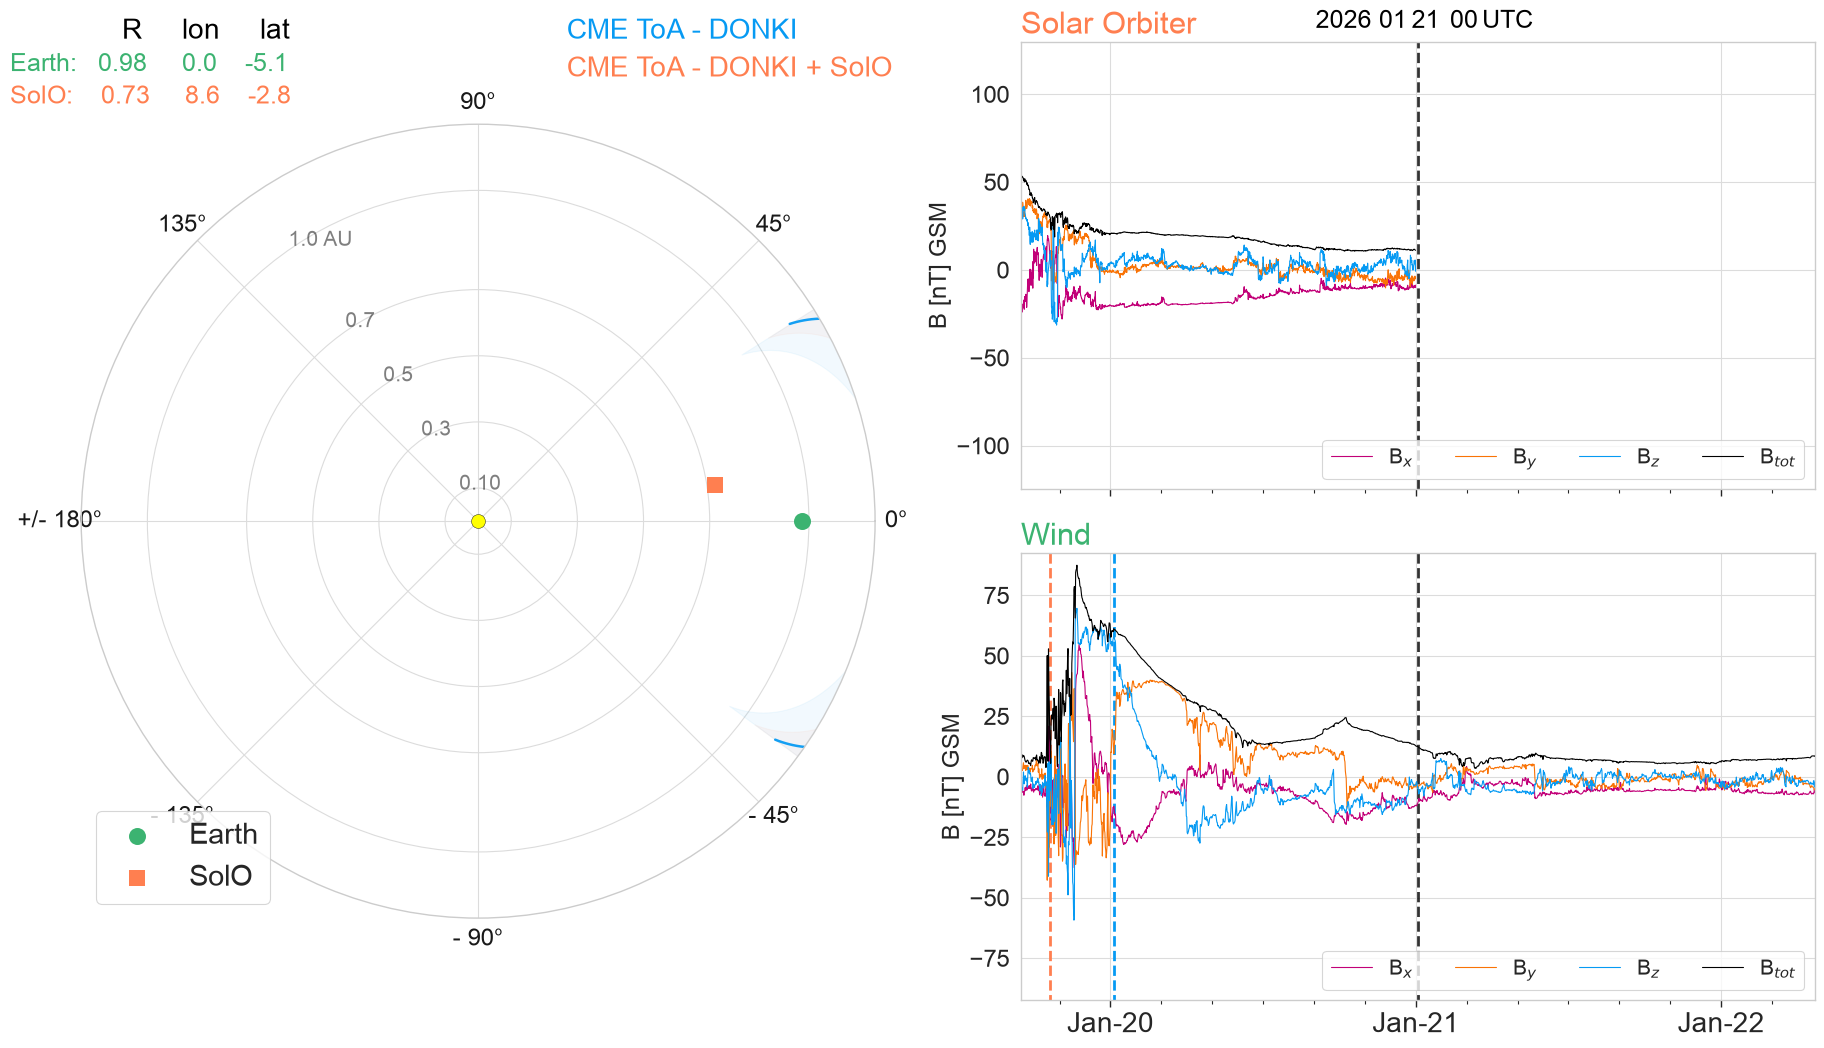

done


In [57]:
#for server
#matplotlib.use('Qt5Agg')

print('Save kinematics plots and overview plot for current time')

%matplotlib inline

start_time=time.time()

#print()
#print('make animation')

#animation start time in matplotlib format

frame_time_num=parse_time(t_start).plot_date
frame_time=t_start

frame_time_num_list = [frame_time_num+k*res_in_days for k in range(k_all)]
#print(hc_time1[0])
#print(mdates.num2date(frame_time_num_list[6]))

#k_today = np.where(frame_time_num_list==mdates.date2num(datetime.now().replace(microsecond=0, second=0, minute=0)))

#frame_index = np.where(frame_time_num_list==mdates.date2num(datetime(2024,3,24,14,10)))[0][0]

#sns.set_context('talk')
#if not black: sns.set_style('darkgrid'),#{'grid.linestyle': ':', 'grid.color': '.35'}) 
#if black: sns.set_style('white',{'grid.linestyle': ':', 'grid.color': '.35'})   

# animation settings 

fsize=18
#fadeind = 200*24 #if s/c positions are given in hourly resolution
#fadeind=int(20/res_in_days)#
fadeind=10/3600. #int(120/res_in_days)

symsize_planet=150
symsize_spacecraft=120

#for parker spiral   
theta=np.arange(0,np.deg2rad(180),0.01)

######################## make frames

#for debugging
#don't close plot in make_frame when testing

#plot_kinematics(hc_time_num1, hc_r1, hc_v1)
####################### plot and save frame with todays date and hour 
#make_frame3(k_today[0][0]) 
make_movie=False#
####################### test animation frames (different frame numbers)
make_frame2(k_all)# k_today[0][0])

#for i in np.arange(1,3,1):
#    make_frame(i)

print('done') 


In [58]:
make_movie = True

if make_movie:
    
    #import multiprocessing
    #import multiprocess as mp
    matplotlib.use('Agg')

    print('Creating ', k_all,' frames')

    print()

    start_time=time.time()

    #number of processes depends on your machines memory; check with command line "top"
    #how much memory is used by all your processesii
    nr_of_processes_used=1
    #print('Using multiprocessing, nr of cores',multiprocessing.cpu_count(), \
     #     'with nr of processes used: ',nr_of_processes_used)

    #run multiprocessing pool to make all movie frames, depending only on frame number

    #pool=mp.get_context('fork').Pool(processes=nr_of_processes_used)

    #pool = mp.Pool(processes=nr_of_processes_used)
    #input=[i for i in range(k_all)]
    input=[i for i in np.arange(2,k_all,1)]
    for i in range(k_all):
        make_frame2(i)
    #pool.close()
    #pool.join()
    #for i in input:
     #   make_frame2(i)

    print('time in min: ',np.round((time.time()-start_time)/60))
    print('plots done, frames saved')


Creating  319  frames

time in min:  2.0
plots done, frames saved


In [59]:
ffmpeg_path=''

os.system(ffmpeg_path+'ffmpeg -r 30 -i output/frames/cospar/jan26/pos_anim_%05d.jpg -b 5000k \
    -r 30 output/elevo_2025nov11.mp4 -y -loglevel warning') 

print('movie done & saved')

Please use -b:a or -b:v, -b is ambiguous


movie done & saved


In [ ]:
n_ensembles = 1000
#time_shift_error = 1./24.*8.

start_time_calculation = time.time()

dst1_input = np.abs(np.random.normal(10, 2, n_ensembles))
dst2_input = np.abs(np.random.normal(6, 1, n_ensembles))
dst3_input = np.abs(np.random.normal(10, 2, n_ensembles))

#btot_array = np.array([np.random.normal(k, m, n_ensembles) for k,m in zip(sc_0.bt, sc_0.bt_err)]) 
#btot_array = np.transpose(btot_array)

#bx_array = np.array([np.random.normal(k, m, n_ensembles) for k,m in zip(sc_0.bx, sc_0.bx_err)]) 
#bx_array = np.transpose(bx_array)

#by_array = np.array([np.random.normal(k, m, n_ensembles) for k,m in zip(sc_0.by, sc_0.by_err)]) 
#by_array = np.transpose(by_array)

#bz_array = np.array([np.random.normal(k, m, n_ensembles) for k,m in zip(sc_0.bz, sc_0.bz_err)]) 
#bz_array = np.transpose(bz_array)

#btot_array = np.array([np.random.normal(k, m, n_ensembles) for k,m in zip(sc_0.bt, sc_0.bt_err)]) 
#btot_array = np.transpose(btot_array)

bx_array = np.array([np.random.normal(k, 1./np.sqrt(3), n_ensembles) for k in sc_0.bx]) 
bx_array = np.transpose(bx_array)

by_array = np.array([np.random.normal(k, 1./np.sqrt(3), n_ensembles) for k in sc_0.by]) 
by_array = np.transpose(by_array)

bz_array = np.array([np.random.normal(k, 1./np.sqrt(3), n_ensembles) for k in sc_0.bz]) 
bz_array = np.transpose(bz_array)

btot_array = np.array([np.random.normal(k, 1., n_ensembles) for k in sc_0.bt]) 
btot_array = np.transpose(btot_array)


speed_array = np.array([np.random.normal(k, 50., n_ensembles) for k in sc_0.vt])
speed_array = np.transpose(speed_array)

density_array = np.abs(np.array([np.random.normal(k, k*0.3, n_ensembles) for k in sc_0.np]))
density_array = np.transpose(density_array)

#btot_array_hour = np.array([np.random.normal(k, np.std([k+m, k, k-m]), n_ensembles) for k,m in zip(sc_0_dst['btot'], sc_0_dst['btot_err'])]) 
#btot_array_hour = np.transpose(btot_array_hour)

#bx_array_hour = np.array([np.random.normal(k, np.std([k+m, k, k-m]), n_ensembles) for k,m in zip(sc_0_dst['bx'], sc_0_dst['bx_err'])]) 
#bx_array_hour = np.transpose(bx_array_hour)

#by_array_hour = np.array([np.random.normal(k, np.std([k+m, k, k-m]), n_ensembles) for k,m in zip(sc_0_dst['by'], sc_0_dst['by_err'])]) 
#by_array_hour = np.transpose(by_array_hour)

#bz_array_hour = np.array([np.random.normal(k, np.std([k+m, k, k-m]), n_ensembles) for k,m in zip(sc_0_dst['bz'], sc_0_dst['bz_err'])]) 
#bz_array_hour = np.transpose(bz_array_hour)

#speed_array_hour = np.array([np.random.normal(k, 50., n_ensembles) for k in sc_0_dst['speed']])
#speed_array_hour = np.transpose(speed_array_hour)

#density_array_hour = np.abs(np.array([np.random.normal(k, np.std([k-0.3*k,k,k+0.3*k]), n_ensembles) for k in sc_0_dst['density']]))
#density_array_hour = np.transpose(density_array_hour)

#random_time_shift = np.random.normal(0, time_shift_error, n_ensembles)

sta_symh = []
sta_symh_err = []
sta_dst = []
sta_dst_err = []
wind_symh = []
wind_dst = []
    
for x in range(n_ensembles):
    


    sta_symh_rand = predict.calc_dst_temerin_li(mdates.date2num(sc_0.time), btot_array[x], bx_array[x], by_array[x], bz_array[x], speed_array[x], speed_array[x], density_array[x], dst1=-dst1_input[x], dst2=-dst2_input[x], dst3=-dst3_input[x], version='2006', linear_t_correction=True, minute_res=True)
    #sta_symh_rand = pred.calc_dst_temerin_li(mdates.date2num(sc_0.time)+random_time_shift[x], btot_array[x], bx_array[x], by_array[x], bz_array[x], speed_array[x], speed_array[x], density_array[x], dst1=-dst1_input[x], dst2=-dst2_input[x], dst3=-dst3_input[x], version='2006', linear_t_correction=True, minute_res=True)

    
    sta_symh.append(sta_symh_rand)
    #sta_symh_err.append(sta_symh_rand_err)
    #wind_symh.append(wind_symh_rand)
    #sta_dst.append(sta_dst_rand)
    #sta_dst_err.append(sta_dst_rand_err)
    #wind_dst.append(wind_dst_rand)

sc_0.symh= np.mean(sta_symh, axis=0)
sc_0.symh_err=np.std(sta_symh,axis=0)
#sc_0['dst_err_max']=np.mean(sta_symh,axis=0)+np.std(sta_symh, axis=0)
#wind_0['dst']= np.mean(wind_symh, axis=0)
#wind_0['dst_err']= np.std(wind_symh, axis=0)

#sc_0_dst['dst']= np.mean(sta_dst, axis=0)
#sc_0_dst['dst_err_min']= np.mean(sta_dst, axis=0)-np.std(sta_dst, axis=0)
#sc_0_dst['dst_err_max']= np.mean(sta_dst, axis=0)+np.std(sta_dst, axis=0)
#wind_0_hour['dst']= np.mean(wind_dst, axis=0)
#wind_0_hour['dst_err']= np.std(wind_dst, axis=0)


end_time_calculation = time.time()

print('Time in seconds needed for calculation: ', round((end_time_calculation-start_time_calculation),1), 'seconds')

AttributeError: recarray has no attribute symh

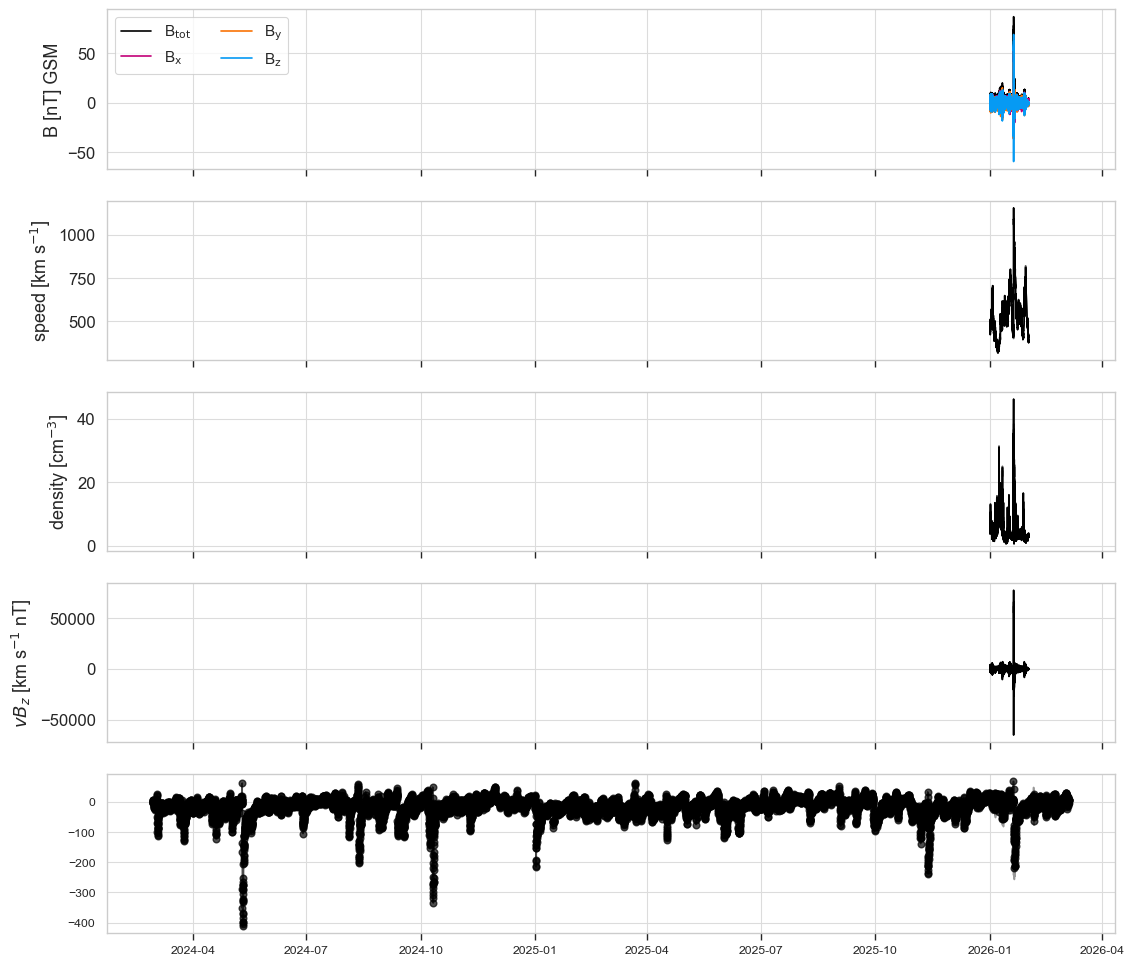

In [181]:
fontsize=13

#print(np.round(np.min(sc_0['dst']),1), np.round(sc_0['dst_err_max'][sc_0['dst']==np.min(sc_0['dst'])]-sc_0['dst_err_min'][sc_0['dst']==np.min(sc_0['dst'])],1)[0])

c0 = "xkcd:black"
c1 = "xkcd:magenta"
c2 = "xkcd:orange"
c3 = "xkcd:azure"

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(13,12), sharex=True)

ax1.plot(sc_0['time'], sc_0['bt'], label=r'B$_{\mathrm{tot}}$', c=c0)
ax1.plot(sc_0['time'], sc_0['bx'], label=r'B$_{\mathrm{x}}$', c=c1)
ax1.plot(sc_0['time'], sc_0['by'], label=r'B$_{\mathrm{y}}$', c=c2)
ax1.plot(sc_0['time'], sc_0['bz'], label=r'B$_{\mathrm{z}}$', c=c3)
#ax1.plot(sc_0_dst['time'], sc_0_dst['btot'], label=r'B$_{\mathrm{tot}}$, hourly sampled', c=c0, alpha=0.5)
ax1.set_ylabel(r'B [nT] GSM', fontsize=fontsize)
ax1.tick_params(axis='y', labelsize=12)
ax1.legend(loc='upper left', fontsize=fontsize-2, ncol=2)

#ax2.plot(sc_0['time'], sc_0['bz'], label=r'B$_{\mathrm{z}}$', c=c0)
##ax2.plot(mdates.num2date(sc_0_dst['time']), sc_0_dst['bz'], label=r'B$_{\mathrm{z}}$, hourly sampled', c=c3, alpha=0.5)
#ax2.set_ylabel(r'B$_{\mathrm{z}}$ [nT]', fontsize=fontsize)
#ax2.tick_params(axis='y', labelsize=12)
##ax2.legend(loc='upper left')

ax2.plot(sc_0['time'], sc_0['vt'], label='Speed, shifted', c=c0)
ax2.plot(l1_input.time, l1_input.vt, label='Speed, orig', c=c0, alpha=0.6)
ax2.set_ylabel('speed [km s$^{-1}$]', fontsize=fontsize)
ax2.tick_params(axis='y', labelsize=12)
#ax3.legend(loc='upper left')

ax3.plot(sc_0['time'], sc_0['np'], label='Density, shifted ', c=c0)
ax3.plot(l1_input.time, l1_input.np, label='Density, orig', c=c0, alpha=0.6)
ax3.set_ylabel('density [cm$^{-3}$]', fontsize=fontsize)
ax3.tick_params(axis='y', labelsize=12)
#ax4.legend(loc='upper left', fontsize=fontsize-2)

ax4.plot(sc_0['time'], (sc_0['vt']*sc_0['bz']), label='vBz', c=c0)
ax4.set_ylabel(r'$vB_z$ [km s$^{-1}$ nT]', fontsize=fontsize)
ax4.tick_params(axis='y', labelsize=12)
#ax4.legend(loc='upper left', fontsize=fontsize-2)

ax5.plot(df_dst.time, df_dst.dst, marker='o', color='black', label=r'$Dst$ index', alpha=0.7)
ax5.plot(omni_input.time, omni_input.symh, color=c0, alpha=0.4, label='SYM-H index')
ax5.plot(sc_0['time'], sc_0.symh, label='modeled SYM-H index', c=c3)

#ax5.fill_between(sc_0['time'], y1=sc_0.symh+sc_0.symh_err, y2=sc_0.symh-sc_0.symh_err, color=c3, alpha=0.4)
ax5.tick_params(axis='x', labelsize=12)
ax5.tick_params(axis='y', labelsize=12)
ax5.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%Y-%m-%d %H:%M') )
ax5.set_ylabel('Strength [nT]', fontsize=fontsize)
ax5.set_xlabel('Time Y-m-d H:M', fontsize=fontsize)
#ax5.set_ylim(-200,100)
ax5.legend(loc='lower left', fontsize=fontsize-2)

#ax6.plot(mdates.num2date(sc_0_dst['time']), sc_0_dst['dst'], label='Dst (calc)', c=c2)
#ax6.fill_between(mdates.num2date(sc_0_dst['time']), y1=sc_0_dst['dst_err_min'], y2=sc_0_dst['dst_err_max'], color=c2, alpha=0.4)
#ax6.set_ylabel('Dst [nT]', fontsize=fontsize)

#ax6.legend(loc='lower left', fontsize=fontsize-2)
#plt.xlim(sc_0['time'][-2000],sc_0['time'][-1])
plt.xlim(datetime(2026,1,19), datetime(2026,1,22))

plt.figtext(0.01,0.97, 'a)', fontsize=15)
plt.figtext(0.01,0.78, 'b)', fontsize=15)
plt.figtext(0.01,0.59, 'c)', fontsize=15)
plt.figtext(0.01,0.40, 'd)', fontsize=15)
plt.figtext(0.01,0.21, 'e)', fontsize=15)

fig.tight_layout()

#plt.savefig('figures/l1_jan2026_SYMH_data_gap_filled_flipped.png')
#plt.close()
plt.show()